# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import skew
from imblearn.over_sampling import SMOTE
import math
from sklearn.feature_selection import SelectKBest, chi2, RFE, f_classif
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df_train = pd.read_csv('train_data.csv')
df_test = pd.read_csv('test_data.csv')
print(df_train.shape)
print(df_test.shape)

(224, 17)
(56, 17)


# Data Overview

In [ ]:
df_train.head()

,id,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,work_type,smoking_status,Heart Disease
0,1,70.0,Female,4,130,322,0,2,109,0,2.4,2,3,3,Private,formerly smoked,Yes
1,2,67.0,Male,3,115,564,0,2,160,0,1.6,2,0,7,Self-employed,never smoked,No
2,3,57.0,Female,2,124,261,0,0,141,0,0.3,1,0,7,Private,never smoked,Yes
3,4,64.0,Female,4,128,263,0,0,105,1,0.2,2,1,7,Private,smokes,No
4,5,74.0,Male,2,120,269,0,2,121,1,0.2,1,1,3,Self-employed,never smoked,No


In [ ]:
df_test.head()

,id,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,work_type,smoking_status,Heart Disease
0,225,41.0,Male,2,130,204,0,2,172,0,1.4,1,0,3,Private,smokes,No
1,226,63.0,Male,3,135,252,0,2,172,0,0.0,1,0,3,Self-employed,never smoked,No
2,227,51.0,Female,3,94,227,0,0,154,1,0.0,1,1,7,Private,smokes,No
3,228,54.0,Female,3,120,258,0,2,147,0,0.4,2,0,7,Self-employed,smokes,No
4,229,44.0,Female,2,120,220,0,0,170,0,0.0,1,0,3,Govt_job,never smoked,No


In [ ]:
df_train.describe()

,id,Age,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,224.000000,220.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000
mean,112.138393,54.550000,3.187500,130.700893,248.044643,0.151786,1.026786,149.245536,0.357143,1.025446,1.602679,0.696429,4.633929
std,64.671738,9.266833,0.961419,18.021034,51.895011,0.359617,0.997394,23.834396,0.480231,1.121668,0.626895,0.940749,1.936182
min,1.000000,29.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,56.750000,47.750000,3.000000,120.000000,212.000000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,112.500000,55.000000,3.000000,130.000000,242.500000,0.000000,2.000000,154.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,168.250000,61.250000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.800000,2.000000,1.000000,7.000000
max,224.000000,77.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,5.600000,3.000000,3.000000,7.000000


In [ ]:
df_test.describe()

,id,Age,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,56.000000,54.000000,56.000000,56.000000,56.000000,56.000000,56.00000,56.000000,56.000000,56.000000,56.000000,56.000000,56.000000
mean,252.517857,53.722222,3.178571,133.625000,250.321429,0.125000,1.00000,152.696429,0.250000,1.153571,1.517857,0.571429,4.785714
std,16.289418,8.995631,0.876089,16.447782,49.633239,0.333712,1.00905,20.639697,0.436931,1.183364,0.602753,0.931414,1.951357
min,225.000000,35.000000,1.000000,94.000000,164.000000,0.000000,0.00000,97.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,238.750000,45.500000,3.000000,120.000000,210.500000,0.000000,0.00000,141.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,252.500000,54.000000,3.000000,132.000000,253.500000,0.000000,1.00000,154.500000,0.000000,1.000000,1.000000,0.000000,3.000000
75%,266.250000,60.750000,4.000000,140.000000,283.250000,0.000000,2.00000,170.250000,0.250000,1.600000,2.000000,1.000000,7.000000
max,280.000000,71.000000,4.000000,180.000000,353.000000,1.000000,2.00000,190.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [ ]:
def data_info(data):

    """
    This function returns a DataFrame containing the summary information for each column
    """

    Names=[col for col in data]
    data_types=[data[col].dtype for col in data.columns]
    top_10_unique_values=[data[col].value_counts().head(10).index.to_list() for col in data.columns]
    nunique_values=[data[col].nunique() for col in data.columns]
    nulls=[data[col].isnull().sum() for col in data.columns]
    percent_of_Nulls= [data[col].isnull().sum()/len(data)*100 for col in data.columns]
    duplicates=data.duplicated().sum()


    info_df=pd.DataFrame({'Name':Names,
                          'Data_Type':data_types,
                          'Top_10_Unique_Values':top_10_unique_values,
                          'Nunique_Values':nunique_values,
                          'Nulls':nulls,
                          'Percent_of_Nulls':percent_of_Nulls,
                          'Duplicates':duplicates})
    return info_df

In [ ]:
data_info(df_train)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,id,int64,"[134, 133, 132, 131, 130, 129, 128, 136, 135, 10]",215,0,0.000000,9
1,Age,float64,"[54.0, 58.0, 57.0, 59.0, 60.0, 42.0, 51.0, 64....",41,4,1.785714,9
2,Gender,object,"[Female, Male]",2,6,2.678571,9
3,Chest pain type,int64,"[4, 3, 2, 1]",4,0,0.000000,9
4,BP,int64,"[120, 140, 130, 110, 150, 125, 112, 160, 128, ...",45,0,0.000000,9
5,Cholesterol,int64,"[269, 234, 226, 211, 177, 230, 197, 246, 233, ...",122,0,0.000000,9
6,FBS over 120,int64,"[0, 1]",2,0,0.000000,9
7,EKG results,int64,"[2, 0, 1]",3,0,0.000000,9
8,Max HR,int64,"[160, 163, 125, 162, 165, 178, 169, 152, 173, ...",81,0,0.000000,9
9,Exercise angina,int64,"[0, 1]",2,0,0.000000,9


In [ ]:
data_info(df_test)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,id,int64,"[235, 226, 225, 228, 229, 230, 227, 231, 232, ...",55,0,0.000000,1
1,Age,float64,"[44.0, 52.0, 60.0, 43.0, 58.0, 65.0, 54.0, 62....",26,2,3.571429,1
2,Gender,object,"[Female, Male]",2,0,0.000000,1
3,Chest pain type,int64,"[4, 3, 2, 1]",4,0,0.000000,1
4,BP,int64,"[130, 120, 140, 150, 138, 110, 135, 160, 118, ...",18,0,0.000000,1
5,Cholesterol,int64,"[263, 183, 219, 252, 204, 220, 258, 227, 239, ...",53,0,0.000000,1
6,FBS over 120,int64,"[0, 1]",2,0,0.000000,1
7,EKG results,int64,"[2, 0]",2,0,0.000000,1
8,Max HR,int64,"[172, 132, 160, 162, 182, 146, 153, 171, 158, ...",38,0,0.000000,1
9,Exercise angina,int64,"[0, 1]",2,0,0.000000,1


# Analysis and Visualizations to get Information about the data

Target distribution

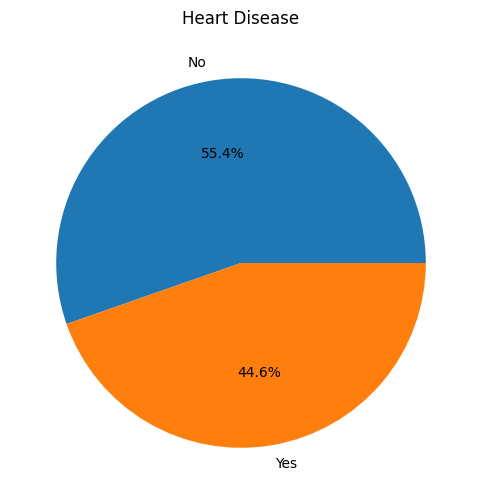

In [ ]:
plt.figure(figsize=(10, 6))
plt.pie(df_train["Heart Disease"].value_counts().values, labels=df_train["Heart Disease"].value_counts().index, autopct='%1.1f%%')
plt.title("Heart Disease")
plt.show()

Numerical Columns

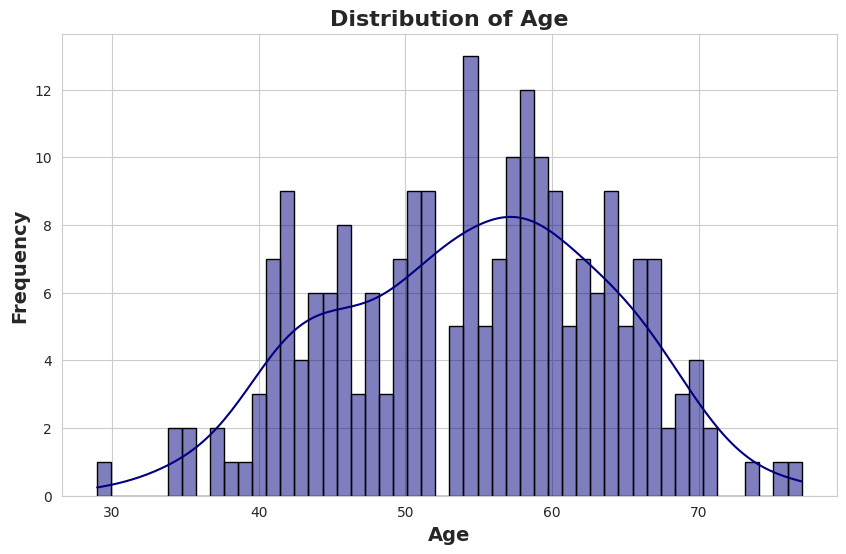

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

sns.histplot(df_train["Age"], bins=50, kde=True, color="navy", edgecolor="black")

plt.xlabel("Age", fontsize=14, fontweight='bold')
plt.ylabel("Frequency", fontsize=14, fontweight='bold')
plt.title("Distribution of Age", fontsize=16, fontweight='bold')

plt.show()

Age is normally distributed

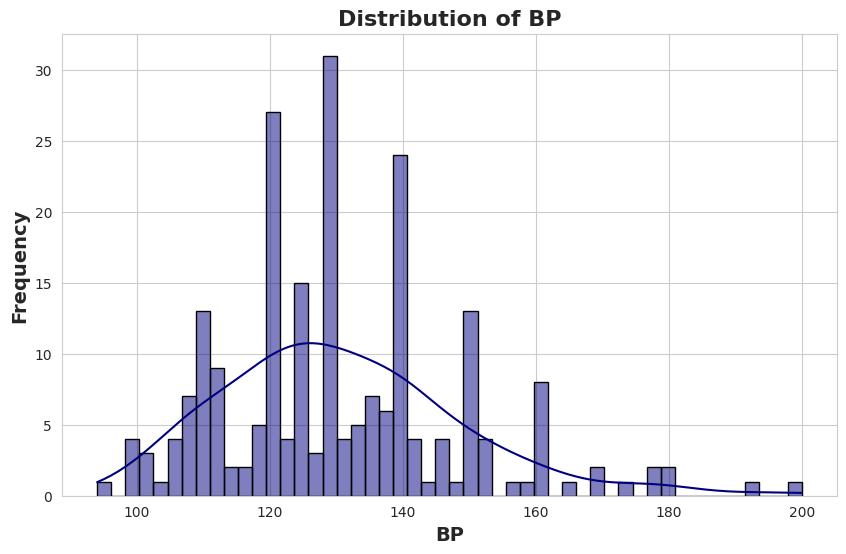

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

sns.histplot(df_train["BP"], bins=50, kde=True, color="navy", edgecolor="black")

plt.xlabel("BP", fontsize=14, fontweight='bold')
plt.ylabel("Frequency", fontsize=14, fontweight='bold')
plt.title("Distribution of BP", fontsize=16, fontweight='bold')

plt.show()

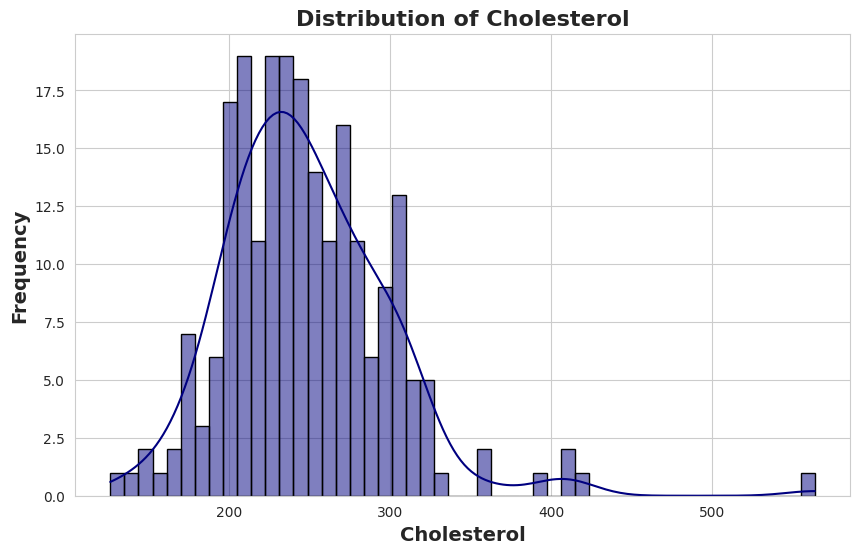

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

sns.histplot(df_train["Cholesterol"], bins=50, kde=True, color="navy", edgecolor="black")

plt.xlabel("Cholesterol", fontsize=14, fontweight='bold')
plt.ylabel("Frequency", fontsize=14, fontweight='bold')
plt.title("Distribution of Cholesterol", fontsize=16, fontweight='bold')

plt.show()

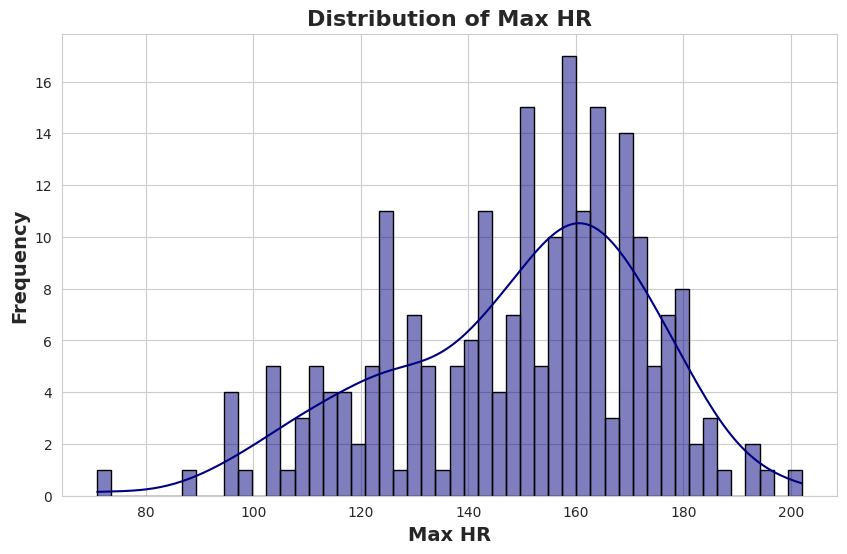

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

sns.histplot(df_train["Max HR"], bins=50, kde=True, color="navy", edgecolor="black")

plt.xlabel("Max HR", fontsize=14, fontweight='bold')
plt.ylabel("Frequency", fontsize=14, fontweight='bold')
plt.title("Distribution of Max HR", fontsize=16, fontweight='bold')

plt.show()

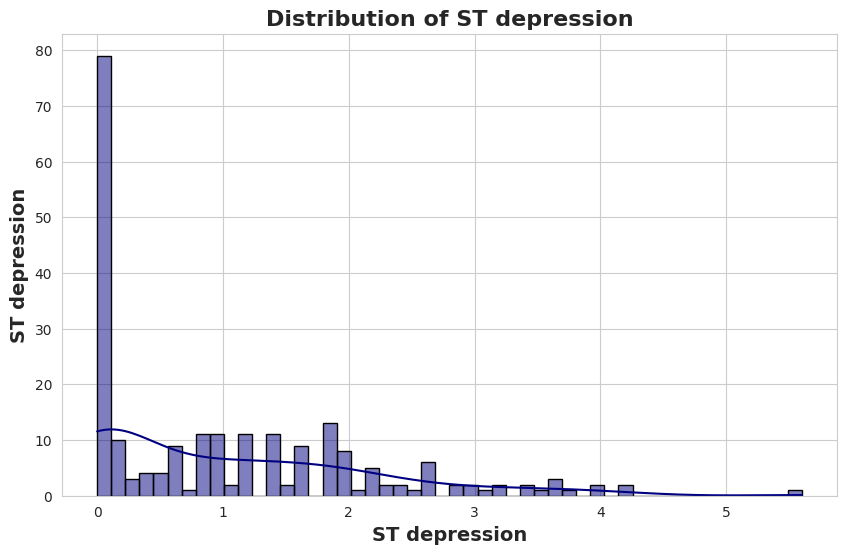

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

sns.histplot(df_train["ST depression"], bins=50, kde=True, color="navy", edgecolor="black")

plt.xlabel("ST depression", fontsize=14, fontweight='bold')
plt.ylabel("ST depression", fontsize=14, fontweight='bold')
plt.title("Distribution of ST depression", fontsize=16, fontweight='bold')

plt.show()

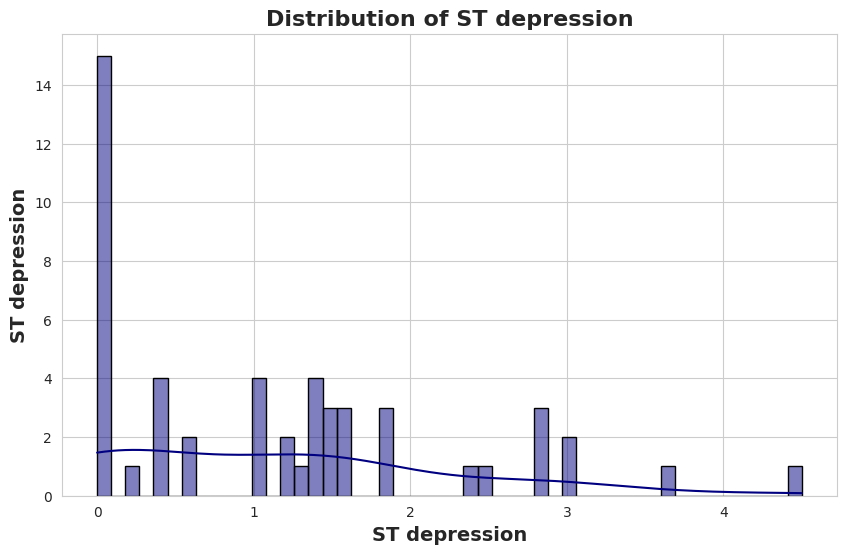

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

sns.histplot(df_test["ST depression"], bins=50, kde=True, color="navy", edgecolor="black")

plt.xlabel("ST depression", fontsize=14, fontweight='bold')
plt.ylabel("ST depression", fontsize=14, fontweight='bold')
plt.title("Distribution of ST depression", fontsize=16, fontweight='bold')

plt.show()

Categorical Columns

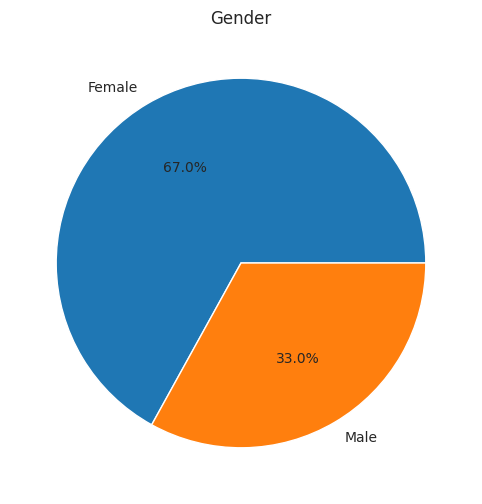

In [ ]:
plt.figure(figsize=(10, 6))
plt.pie(df_train["Gender"].value_counts().values, labels=df_train["Gender"].value_counts().index, autopct='%1.1f%%')
plt.title("Gender")
plt.show()

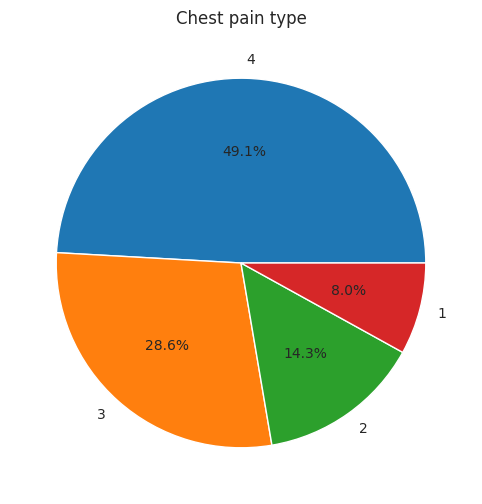

In [ ]:
plt.figure(figsize=(10, 6))
plt.pie(df_train["Chest pain type"].value_counts().values, labels=df_train["Chest pain type"].value_counts().index, autopct='%1.1f%%')
plt.title("Chest pain type")
plt.show()

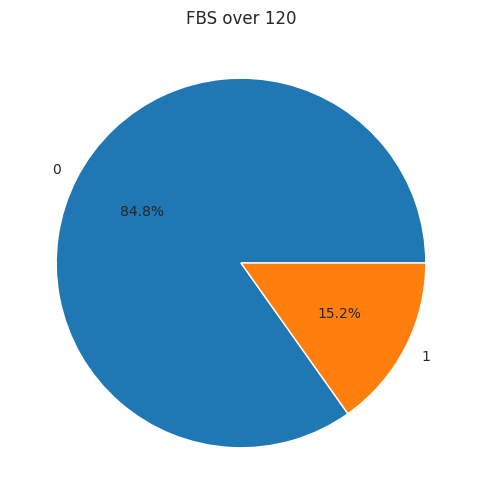

In [ ]:
plt.figure(figsize=(10, 6))
plt.pie(df_train["FBS over 120"].value_counts().values, labels=df_train["FBS over 120"].value_counts().index, autopct='%1.1f%%')
plt.title("FBS over 120")
plt.show()

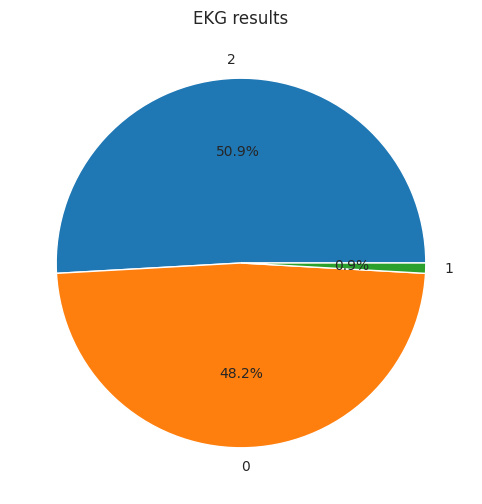

In [ ]:
plt.figure(figsize=(10, 6))
plt.pie(df_train["EKG results"].value_counts().values, labels=df_train["EKG results"].value_counts().index, autopct='%1.1f%%')
plt.title("EKG results")
plt.show()

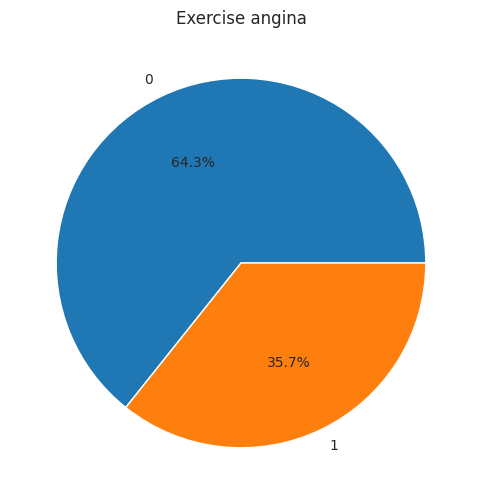

In [ ]:
plt.figure(figsize=(10, 6))
plt.pie(df_train["Exercise angina"].value_counts().values, labels=df_train["Exercise angina"].value_counts().index, autopct='%1.1f%%')
plt.title("Exercise angina")
plt.show()

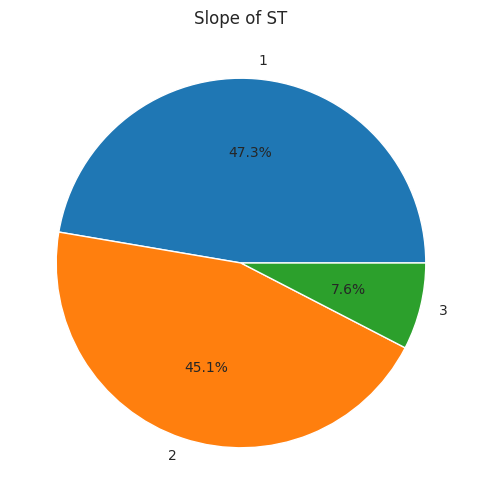

In [ ]:
plt.figure(figsize=(10, 6))
plt.pie(df_train["Slope of ST"].value_counts().values, labels=df_train["Slope of ST"].value_counts().index, autopct='%1.1f%%')
plt.title("Slope of ST")
plt.show()

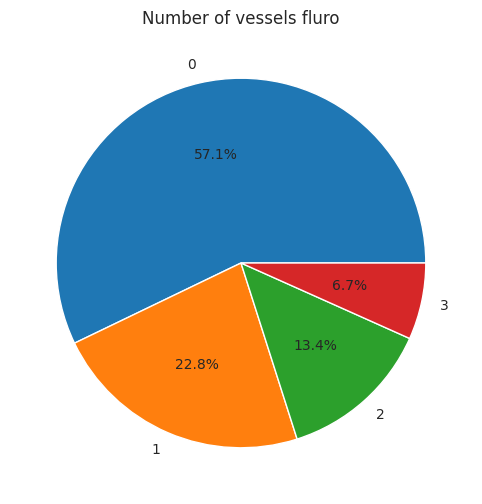

In [ ]:
plt.figure(figsize=(10, 6))
plt.pie(df_train["Number of vessels fluro"].value_counts().values, labels=df_train["Number of vessels fluro"].value_counts().index, autopct='%1.1f%%')
plt.title("Number of vessels fluro")
plt.show()

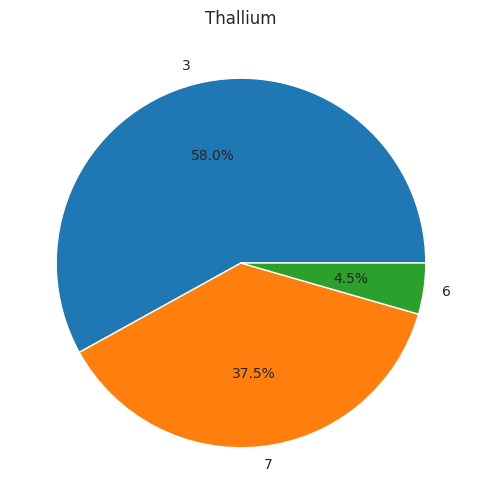

In [ ]:
plt.figure(figsize=(10, 6))
plt.pie(df_train["Thallium"].value_counts().values, labels=df_train["Thallium"].value_counts().index, autopct='%1.1f%%')
plt.title("Thallium")
plt.show()

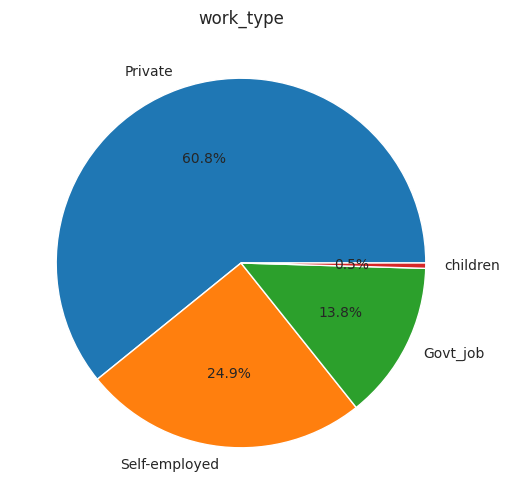

In [ ]:
plt.figure(figsize=(10, 6))
plt.pie(df_train["work_type"].value_counts().values, labels=df_train["work_type"].value_counts().index, autopct='%1.1f%%')
plt.title("work_type")
plt.show()

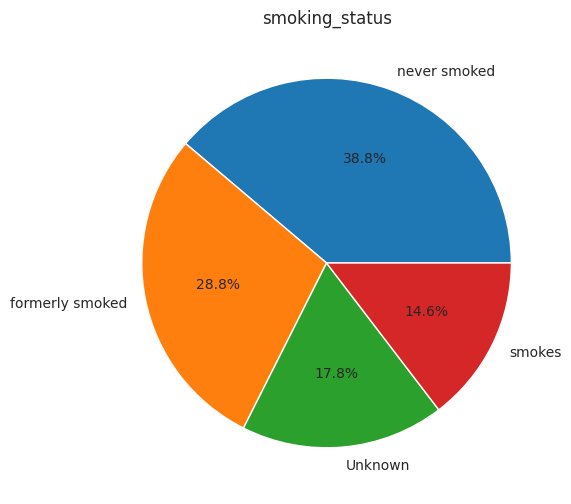

In [ ]:
plt.figure(figsize=(10, 6))
plt.pie(df_train["smoking_status"].value_counts().values, labels=df_train["smoking_status"].value_counts().index, autopct='%1.1f%%')
plt.title("smoking_status")
plt.show()

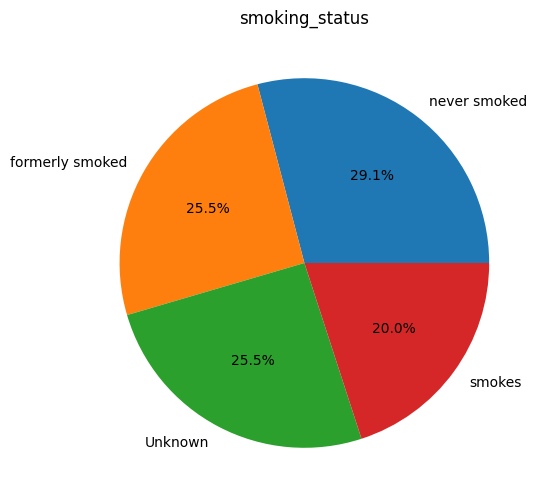

In [ ]:
plt.figure(figsize=(10, 6))
plt.pie(df_test["smoking_status"].value_counts().values, labels=df_train["smoking_status"].value_counts().index, autopct='%1.1f%%')
plt.title("smoking_status")
plt.show()

Columns with Target

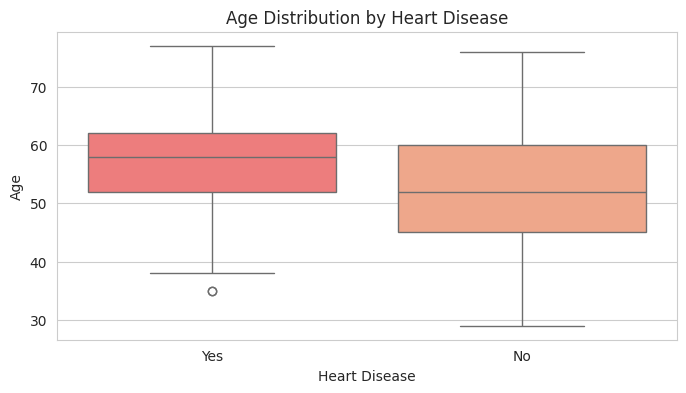

In [ ]:

plt.figure(figsize=(8, 4))
sns.boxplot(x='Heart Disease', y='Age', data=df_train, palette=['#FF6B6B', '#FFA07A'])
plt.title('Age Distribution by Heart Disease')
plt.ylabel('Age')
plt.xlabel('Heart Disease')
plt.show()

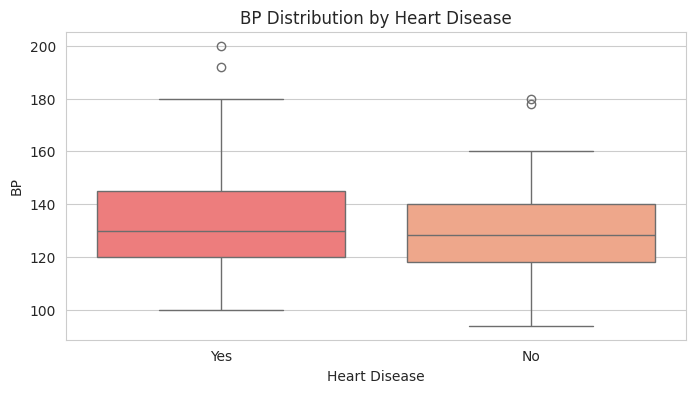

In [ ]:

plt.figure(figsize=(8, 4))
sns.boxplot(x='Heart Disease', y='BP', data=df_train, palette=['#FF6B6B', '#FFA07A'])
plt.title('BP Distribution by Heart Disease')
plt.ylabel('BP')
plt.xlabel('Heart Disease')
plt.show()

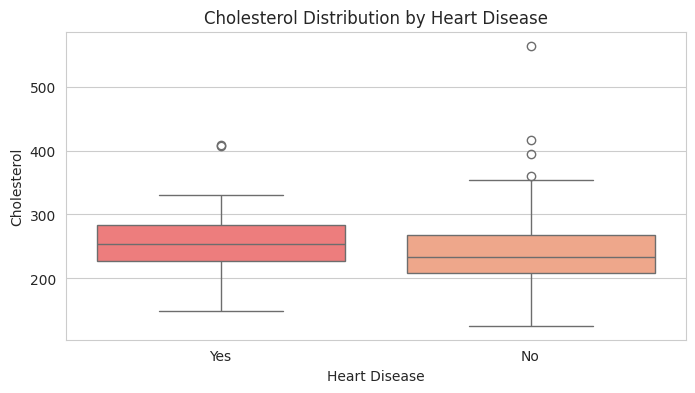

In [ ]:

plt.figure(figsize=(8, 4))
sns.boxplot(x='Heart Disease', y='Cholesterol', data=df_train, palette=['#FF6B6B', '#FFA07A'])
plt.title('Cholesterol Distribution by Heart Disease')
plt.ylabel('Cholesterol')
plt.xlabel('Heart Disease')
plt.show()

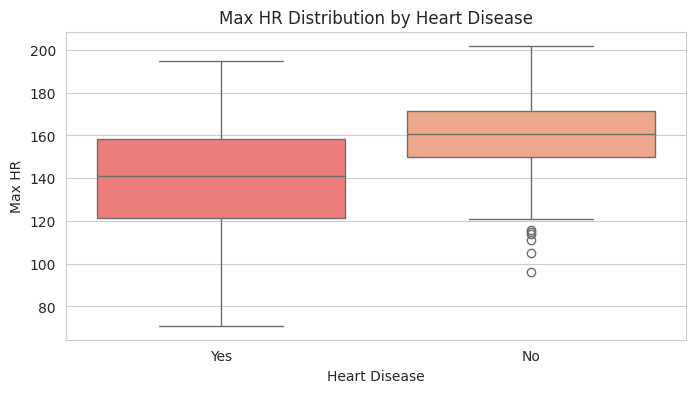

In [ ]:

plt.figure(figsize=(8, 4))
sns.boxplot(x='Heart Disease', y='Max HR', data=df_train, palette=['#FF6B6B', '#FFA07A'])
plt.title('Max HR Distribution by Heart Disease')
plt.ylabel('Max HR')
plt.xlabel('Heart Disease')
plt.show()

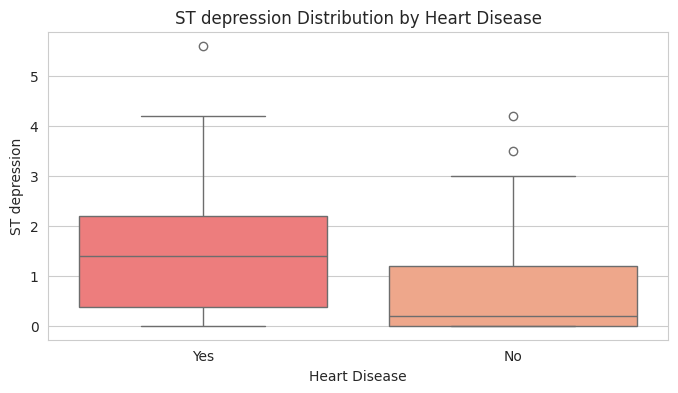

In [ ]:

plt.figure(figsize=(8, 4))
sns.boxplot(x='Heart Disease', y='ST depression', data=df_train, palette=['#FF6B6B', '#FFA07A'])
plt.title('ST depression Distribution by Heart Disease')
plt.ylabel('ST depression')
plt.xlabel('Heart Disease')
plt.show()

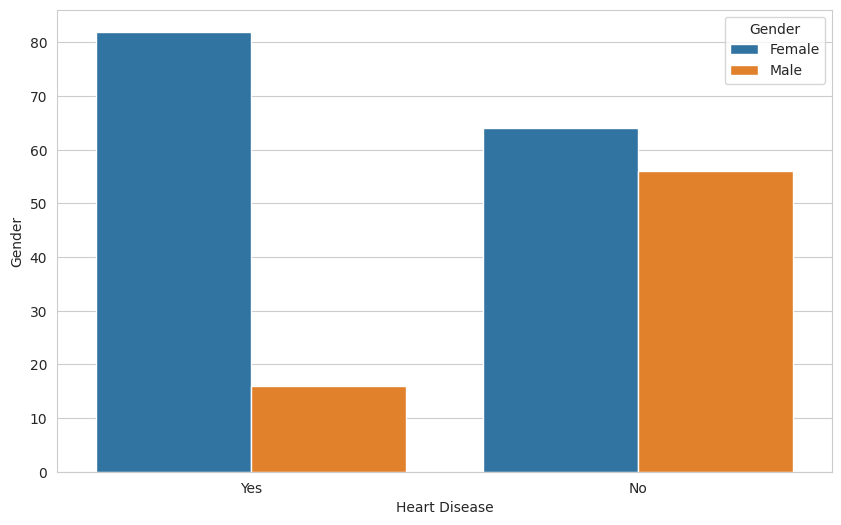

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_train, x='Heart Disease', hue='Gender')
plt.xlabel('Heart Disease')
plt.ylabel('Gender')
plt.legend(title='Gender')
plt.show()

The majority of heart disease patients are female

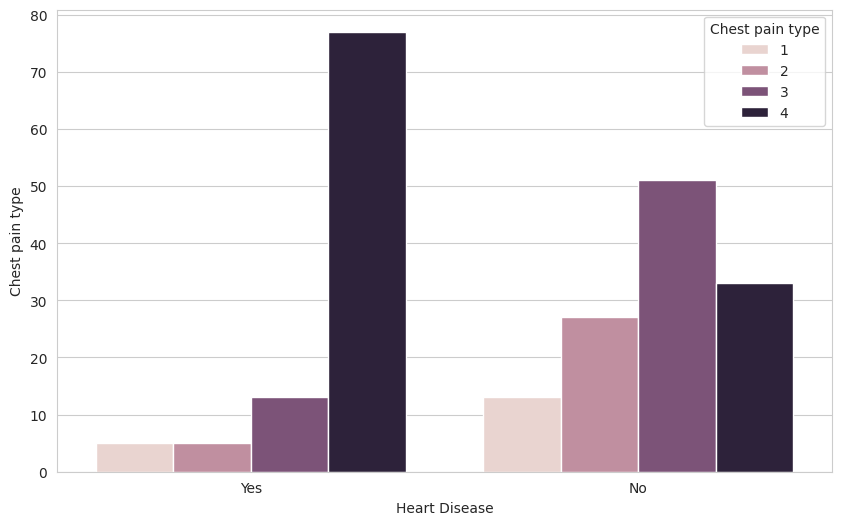

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_train, x='Heart Disease', hue='Chest pain type')
plt.xlabel('Heart Disease')
plt.ylabel('Chest pain type')
plt.legend(title='Chest pain type')
plt.show()

Most heart disease patients have chest pain type 4

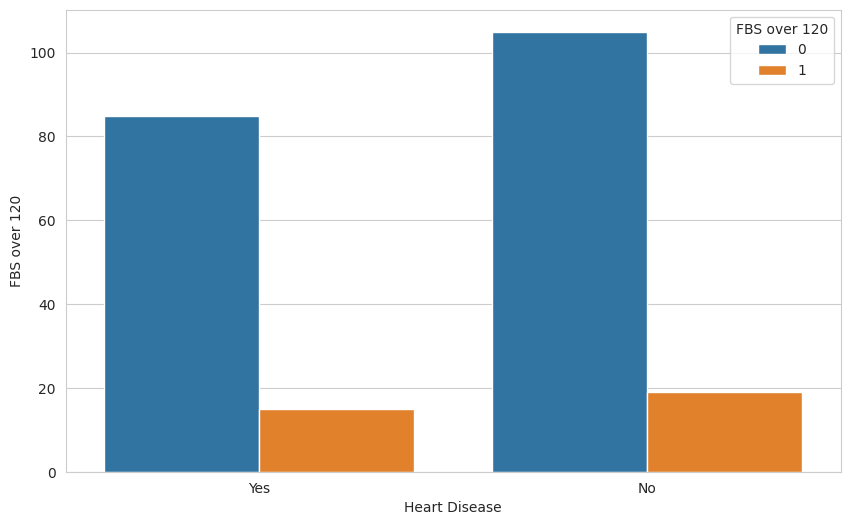

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_train, x='Heart Disease', hue='FBS over 120')
plt.xlabel('Heart Disease')
plt.ylabel('FBS over 120')
plt.legend(title='FBS over 120')
plt.show()

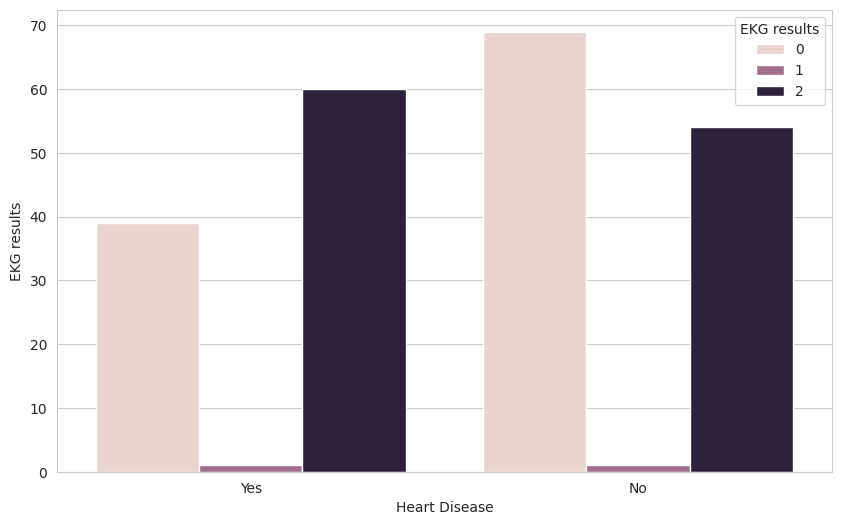

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_train, x='Heart Disease', hue='EKG results')
plt.xlabel('Heart Disease')
plt.ylabel('EKG results')
plt.legend(title='EKG results')
plt.show()

Most EKG = 0 have not heart disease

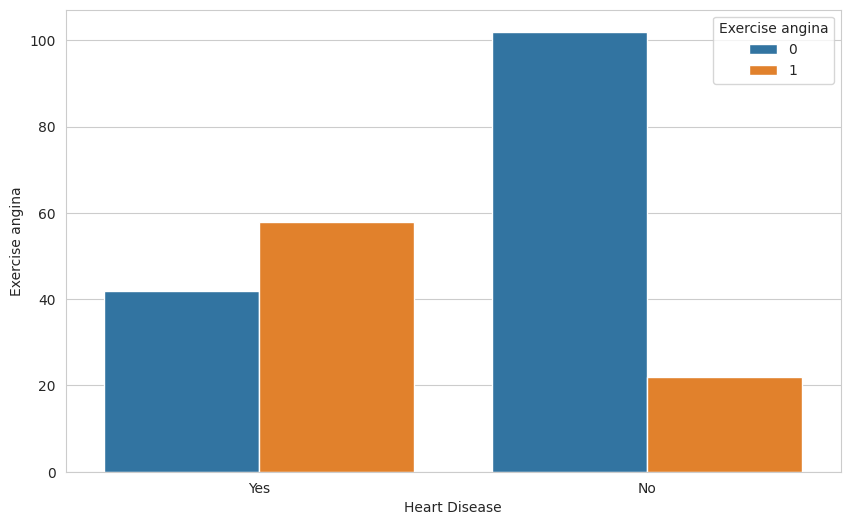

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_train, x='Heart Disease', hue='Exercise angina')
plt.xlabel('Heart Disease')
plt.ylabel('Exercise angina')
plt.legend(title='Exercise angina')
plt.show()

Most EA = 0 have not heart disease

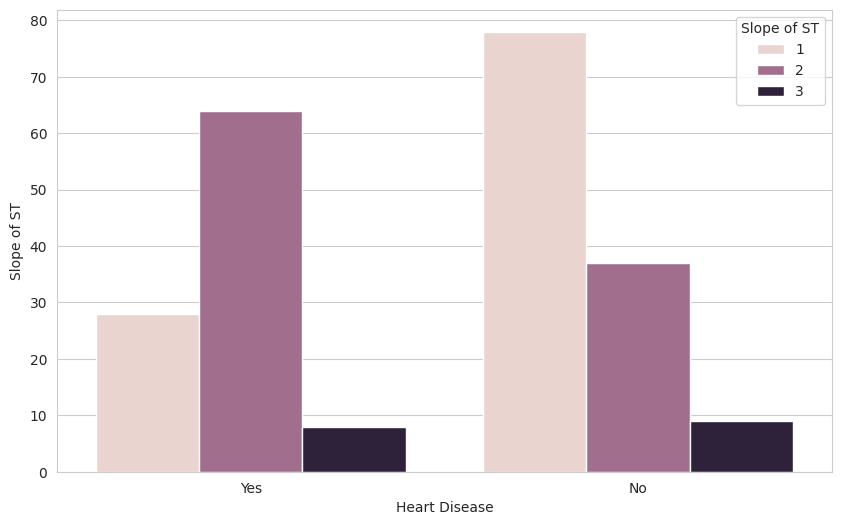

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_train, x='Heart Disease', hue='Slope of ST')
plt.xlabel('Heart Disease')
plt.ylabel('Slope of ST')
plt.legend(title='Slope of ST')
plt.show()

Most slope = 1 have not heart disease

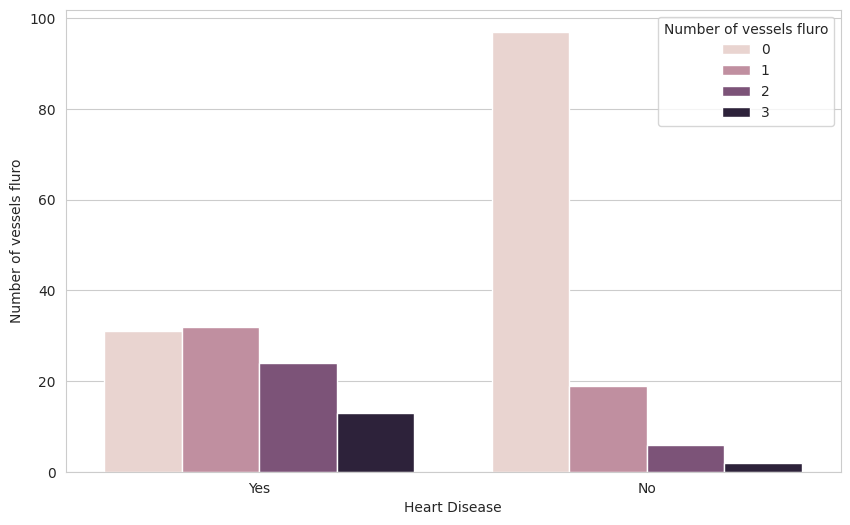

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_train, x='Heart Disease', hue='Number of vessels fluro')
plt.xlabel('Heart Disease')
plt.ylabel('Number of vessels fluro')
plt.legend(title='Number of vessels fluro')
plt.show()

The maximum vessels fluro the higher percentage of having a heart disease

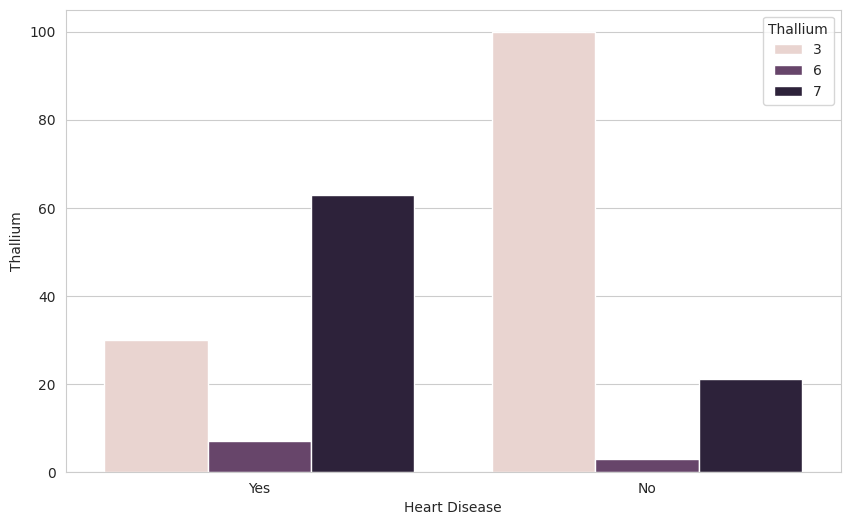

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_train, x='Heart Disease', hue='Thallium')
plt.xlabel('Heart Disease')
plt.ylabel('Thallium')
plt.legend(title='Thallium')
plt.show()

Thallium = 3 appears protective, while Thallium = 7 is associated with disease

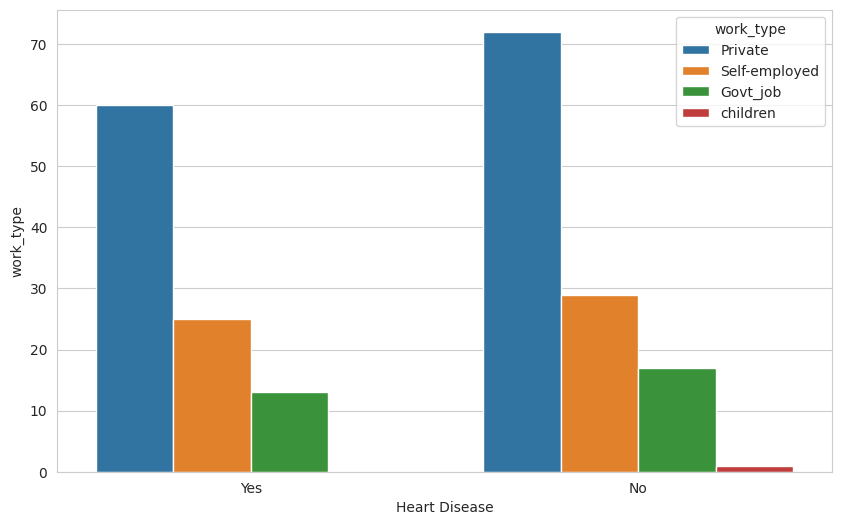

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_train, x='Heart Disease', hue='work_type')
plt.xlabel('Heart Disease')
plt.ylabel('work_type')
plt.legend(title='work_type')
plt.show()

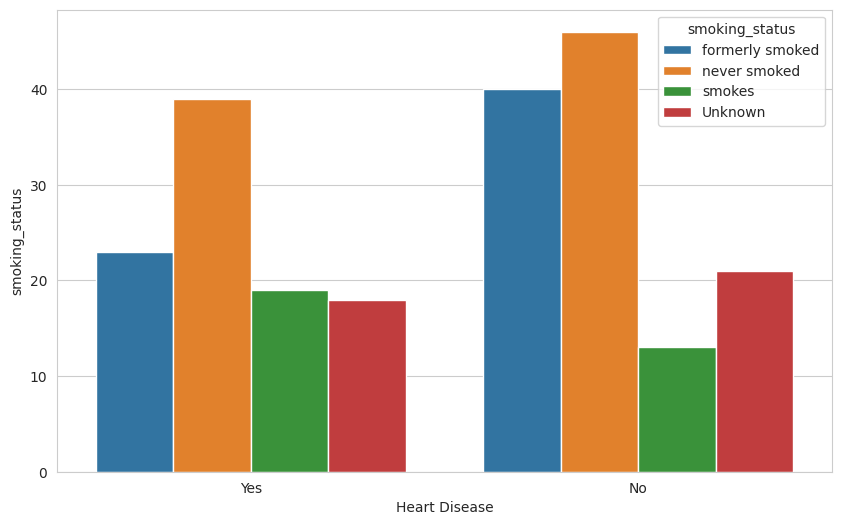

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_train, x='Heart Disease', hue='smoking_status')
plt.xlabel('Heart Disease')
plt.ylabel('smoking_status')
plt.legend(title='smoking_status')
plt.show()

Smoking increases the risk of heart disease

#Columns Relations

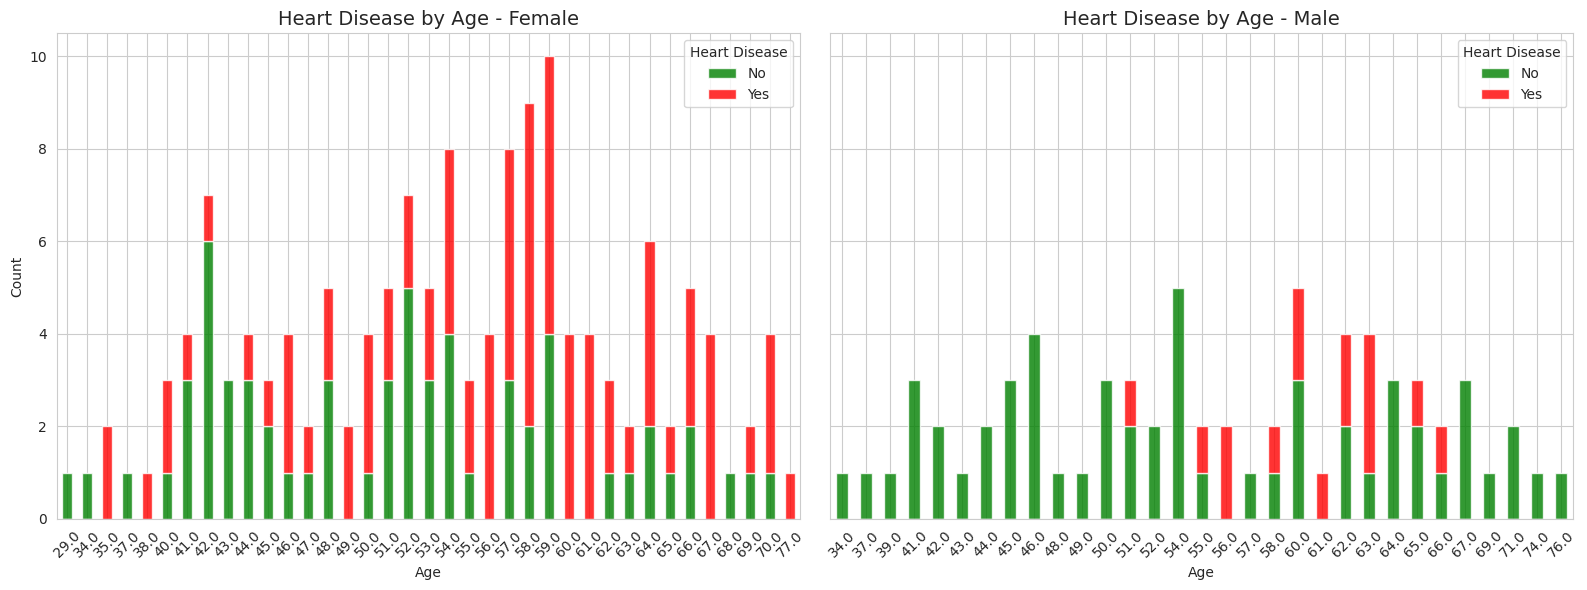

In [ ]:

# Gender - Age - Disease
cross_3d = pd.crosstab([df_train['Age'], df_train['Gender']], df_train['Heart Disease'])


fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, gender in zip(axes, ['Female', 'Male']):
    gender_data = cross_3d.xs(gender, level='Gender')
    gender_data.plot(kind='bar', stacked=True, ax=ax, color=['green', 'red'], alpha=0.8)
    ax.set_title(f'Heart Disease by Age - {gender}', fontsize=14)
    ax.set_xlabel('Age')
    ax.set_ylabel('Count')
    ax.legend(title='Heart Disease', labels=['No', 'Yes'])
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

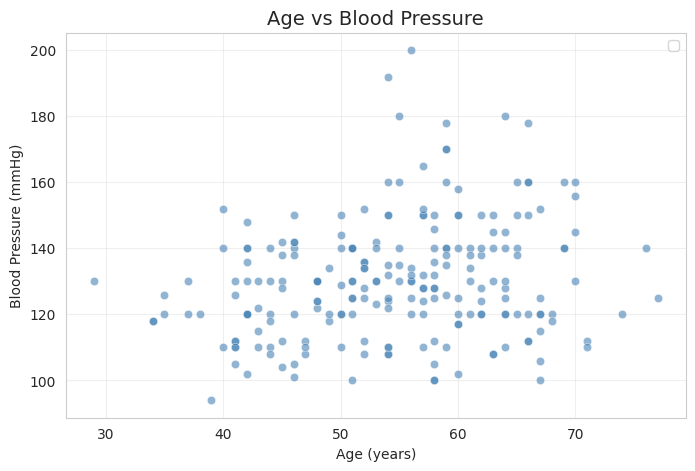

In [ ]:

from scipy import stats

plt.figure(figsize=(8, 5))


sns.scatterplot(x='Age', y='BP', data=df_train, color='steelblue', alpha=0.6)

plt.title('Age vs Blood Pressure', fontsize=14)
plt.xlabel('Age (years)')
plt.ylabel('Blood Pressure (mmHg)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Older age tends to be associated with higher blood pressure

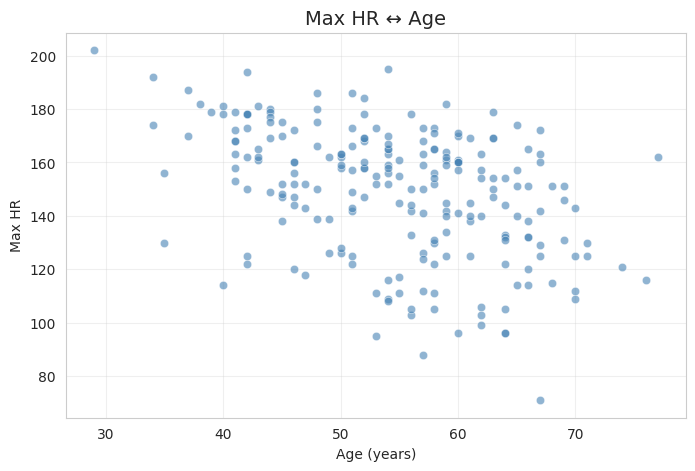

In [ ]:
plt.figure(figsize=(8, 5))


sns.scatterplot(x='Age', y='Max HR', data=df_train,
                alpha=0.6, color='steelblue')


corr = df_train['Age'].corr(df_train['Max HR'])

plt.title(f'Max HR ↔ Age', fontsize=14)
plt.xlabel('Age (years)')
plt.ylabel('Max HR')
plt.grid(True, alpha=0.3)
plt.show()

Older patients tend to have slower maximum heart rates

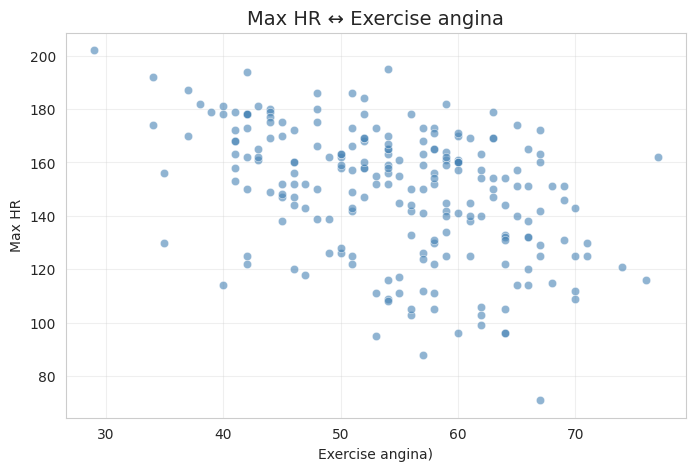

In [ ]:
plt.figure(figsize=(8, 5))


sns.scatterplot(x='Age', y='Max HR', data=df_train,
                alpha=0.6, color='steelblue')


corr = df_train['Exercise angina'].corr(df_train['Max HR'])

plt.title(f'Max HR ↔ Exercise angina', fontsize=14)
plt.xlabel('Exercise angina)')
plt.ylabel('Max HR')
plt.grid(True, alpha=0.3)
plt.show()

Patients with exercise-induced angina tend to have lower maximum heart rates

# Preprocessing

In [ ]:
df_train.drop(columns=['id'], inplace=True)
df_test.drop(columns=['id'], inplace=True)

In [ ]:
df_train.drop(columns=['smoking_status'], inplace=True)
df_test.drop(columns=['smoking_status'], inplace=True)


In [ ]:
df_train = df_train.dropna(subset=['Age'])
df_train['Age'] = df_train['Age'].astype('int64')

df_test = df_test.dropna(subset=['Age'])
df_test['Age'] = df_test['Age'].astype('int64')

In [ ]:
df_train = df_train.dropna(subset=['Gender'])

In [ ]:
df_train['Chest pain type'] = df_train['Chest pain type'].astype(object)
df_test['Chest pain type'] = df_test['Chest pain type'].astype(object)

In [ ]:
df_train['FBS over 120'] = df_train['FBS over 120'].astype(object)
df_test['FBS over 120'] = df_test['FBS over 120'].astype(object)

In [ ]:
df_train['EKG results'] = df_train['EKG results'].astype(object)
df_test['EKG results'] = df_test['EKG results'].astype(object)

In [ ]:
df_train['Exercise angina'] = df_train['Exercise angina'].astype(object)
df_test['Exercise angina'] = df_test['Exercise angina'].astype(object)

In [ ]:
df_train['Slope of ST'] = df_train['Slope of ST'].astype(object)
df_test['Slope of ST'] = df_test['Slope of ST'].astype(object)

In [ ]:
df_train['Number of vessels fluro'] = df_train['Number of vessels fluro'].astype(object)
df_test['Number of vessels fluro'] = df_test['Number of vessels fluro'].astype(object)

In [ ]:
df_train['Thallium'] = df_train['Thallium'].astype(object)
df_test['Thallium'] = df_test['Thallium'].astype(object)

In [ ]:
df_train = df_train.dropna(subset=['work_type'])
df_test = df_test.dropna(subset=['work_type'])

In [ ]:
"""
df_train['smoking_status'] = df_train['smoking_status'].fillna(df_train['smoking_status'].mode()[0])
df_train['smoking_status'] = df_train['smoking_status'].replace('Unknown',df_train['smoking_status'].mode()[0])
df_test['smoking_status'] = df_test['smoking_status'].fillna(df_train['smoking_status'].mode()[0])
df_test['smoking_status'] = df_test['smoking_status'].replace('Unknown',df_train['smoking_status'].mode()[0])
"""

"\ndf_train['smoking_status'] = df_train['smoking_status'].fillna(df_train['smoking_status'].mode()[0])\ndf_train['smoking_status'] = df_train['smoking_status'].replace('Unknown',df_train['smoking_status'].mode()[0])\ndf_test['smoking_status'] = df_test['smoking_status'].fillna(df_train['smoking_status'].mode()[0])\ndf_test['smoking_status'] = df_test['smoking_status'].replace('Unknown',df_train['smoking_status'].mode()[0])\n"

In [ ]:
df_train = df_train.drop_duplicates()
df_test = df_test.drop_duplicates()

In [ ]:
df_train.shape

(198, 15)

In [ ]:
df_test.shape

(51, 15)

In [ ]:
data_info(df_train)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,Age,int64,"[54, 58, 57, 59, 60, 42, 46, 64, 67, 41]",41,0,0.0,0
1,Gender,object,"[Female, Male]",2,0,0.0,0
2,Chest pain type,object,"[4, 3, 2, 1]",4,0,0.0,0
3,BP,int64,"[120, 130, 140, 110, 150, 160, 125, 112, 128, ...",44,0,0.0,0
4,Cholesterol,int64,"[234, 226, 197, 233, 204, 256, 288, 246, 269, ...",118,0,0.0,0
5,FBS over 120,object,"[0, 1]",2,0,0.0,0
6,EKG results,object,"[2, 0, 1]",3,0,0.0,0
7,Max HR,int64,"[163, 162, 125, 152, 165, 150, 140, 178, 156, ...",79,0,0.0,0
8,Exercise angina,object,"[0, 1]",2,0,0.0,0
9,ST depression,float64,"[0.0, 1.2, 0.2, 0.8, 1.6, 1.0, 2.0, 0.6, 1.4, ...",37,0,0.0,0


In [ ]:
data_info(df_test)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,Age,int64,"[44, 60, 43, 58, 54, 51, 52, 62, 63, 41]",26,0,0.0,0
1,Gender,object,"[Female, Male]",2,0,0.0,0
2,Chest pain type,object,"[4, 3, 2, 1]",4,0,0.0,0
3,BP,int64,"[120, 130, 140, 150, 110, 138, 160, 135, 118, ...",16,0,0.0,0
4,Cholesterol,int64,"[219, 204, 252, 227, 220, 258, 254, 168, 330, ...",50,0,0.0,0
5,FBS over 120,object,"[0, 1]",2,0,0.0,0
6,EKG results,object,"[2, 0]",2,0,0.0,0
7,Max HR,int64,"[172, 132, 160, 182, 146, 162, 153, 158, 142, ...",37,0,0.0,0
8,Exercise angina,object,"[0, 1]",2,0,0.0,0
9,ST depression,float64,"[0.0, 1.4, 0.4, 1.0, 2.8, 1.6, 1.8, 1.5, 3.0, ...",17,0,0.0,0


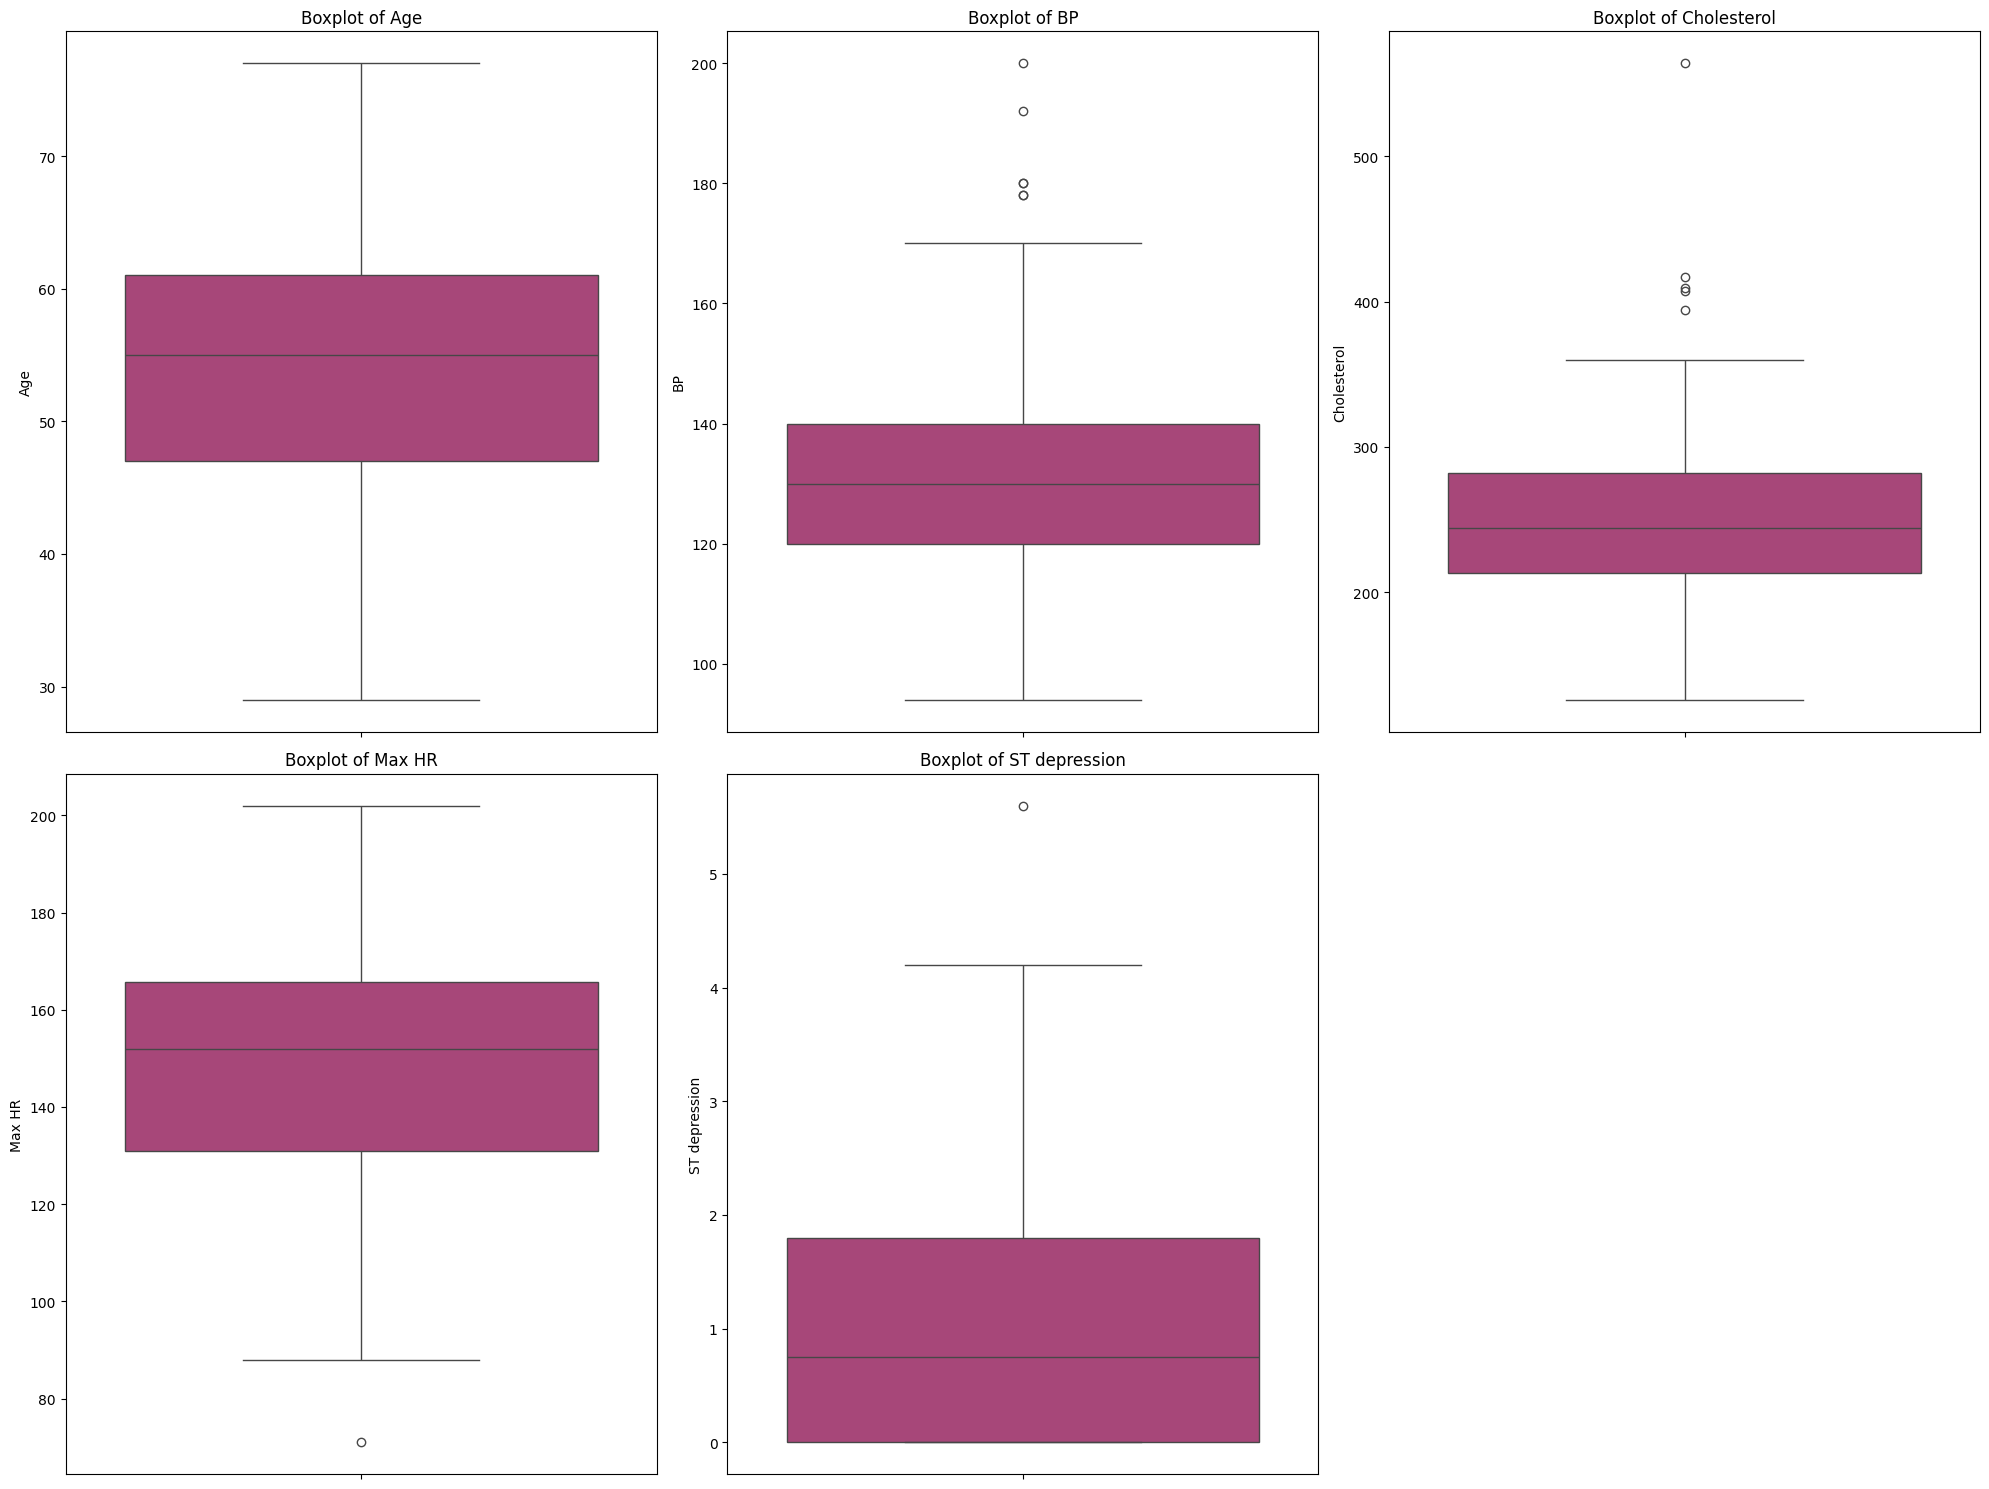

In [ ]:
checkOutliers=["Age","BP", "Cholesterol", "Max HR", "ST depression"]

fig, axes = plt.subplots(2, 3, figsize=(20, 15))

axes = axes.flatten()

for i, col in enumerate(checkOutliers):
    sns.boxplot(data= df_train, y=col, ax=axes[i], palette='magma',whis=1.5)
    axes[i].set_title(f'Boxplot of {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

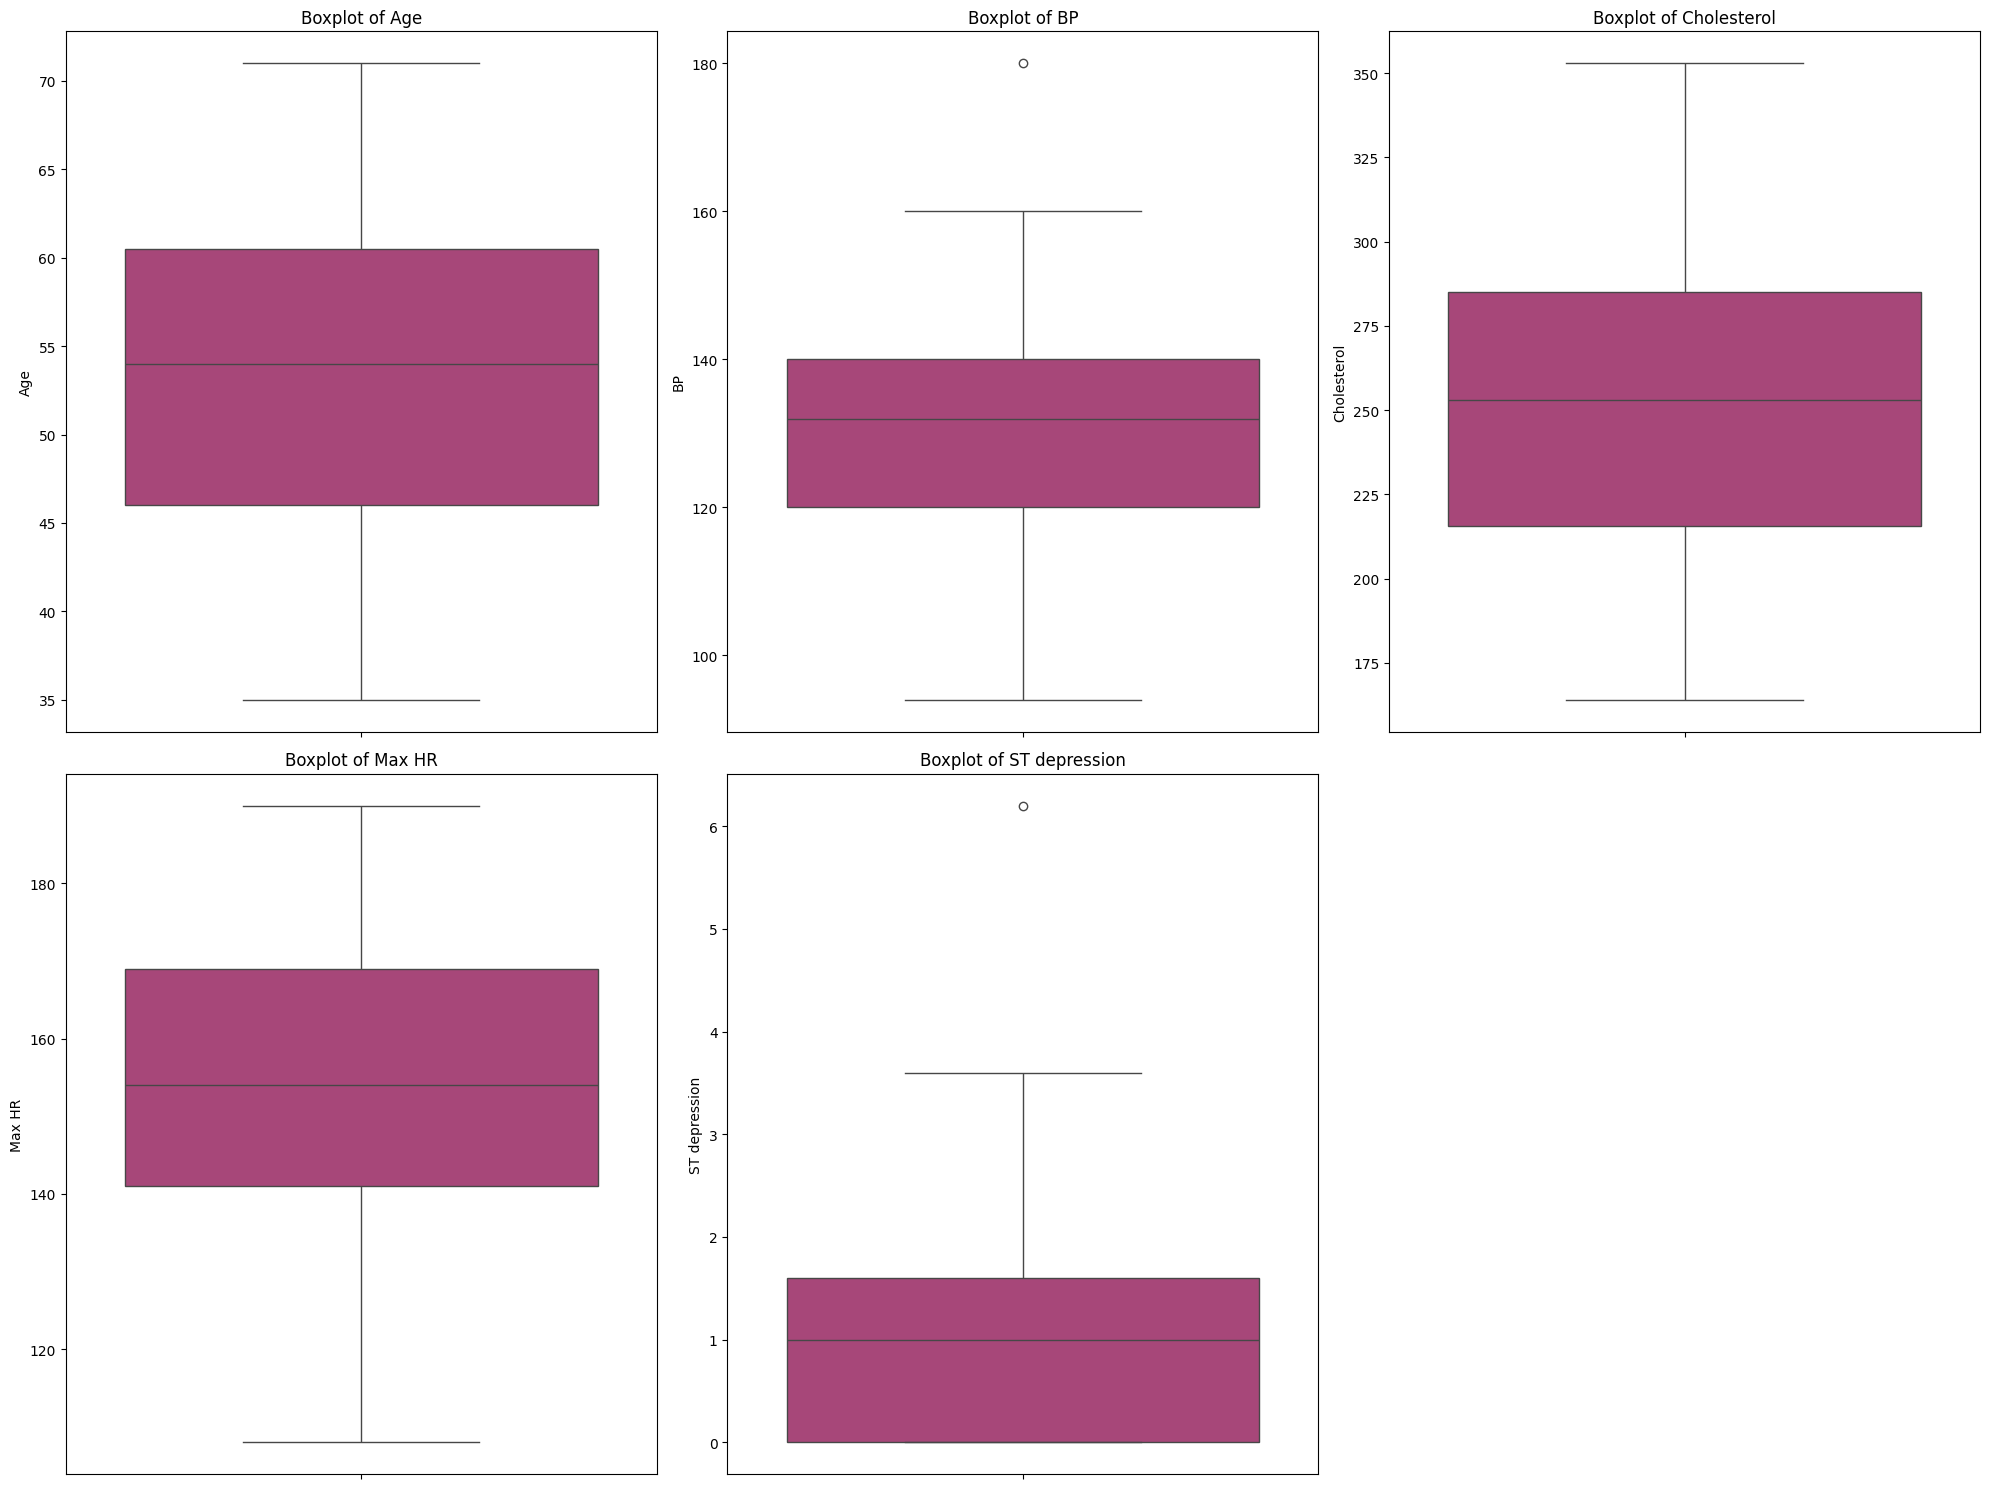

In [ ]:
checkOutliers=["Age","BP", "Cholesterol", "Max HR", "ST depression"]

fig, axes = plt.subplots(2, 3, figsize=(20, 15))

axes = axes.flatten()

for i, col in enumerate(checkOutliers):
    sns.boxplot(data= df_test, y=col, ax=axes[i], palette='magma',whis=1.5)
    axes[i].set_title(f'Boxplot of {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Function to handle outliers of data Train
def handle_Numerical_outliers(data):
    """
    This function handles outliers and returns bounds dictionary.
    """
    num_cols = data.select_dtypes(include="number").columns
    bounds_dict = {}

    for col in num_cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)


        bounds_dict[col] = (lower_bound, upper_bound)


        data[col] = data[col].clip(lower=lower_bound, upper=upper_bound)

    return bounds_dict

In [ ]:
dfTemp_train=df_train[checkOutliers]

In [ ]:
bounds = handle_Numerical_outliers(dfTemp_train)

df_train[checkOutliers]=dfTemp_train[checkOutliers]

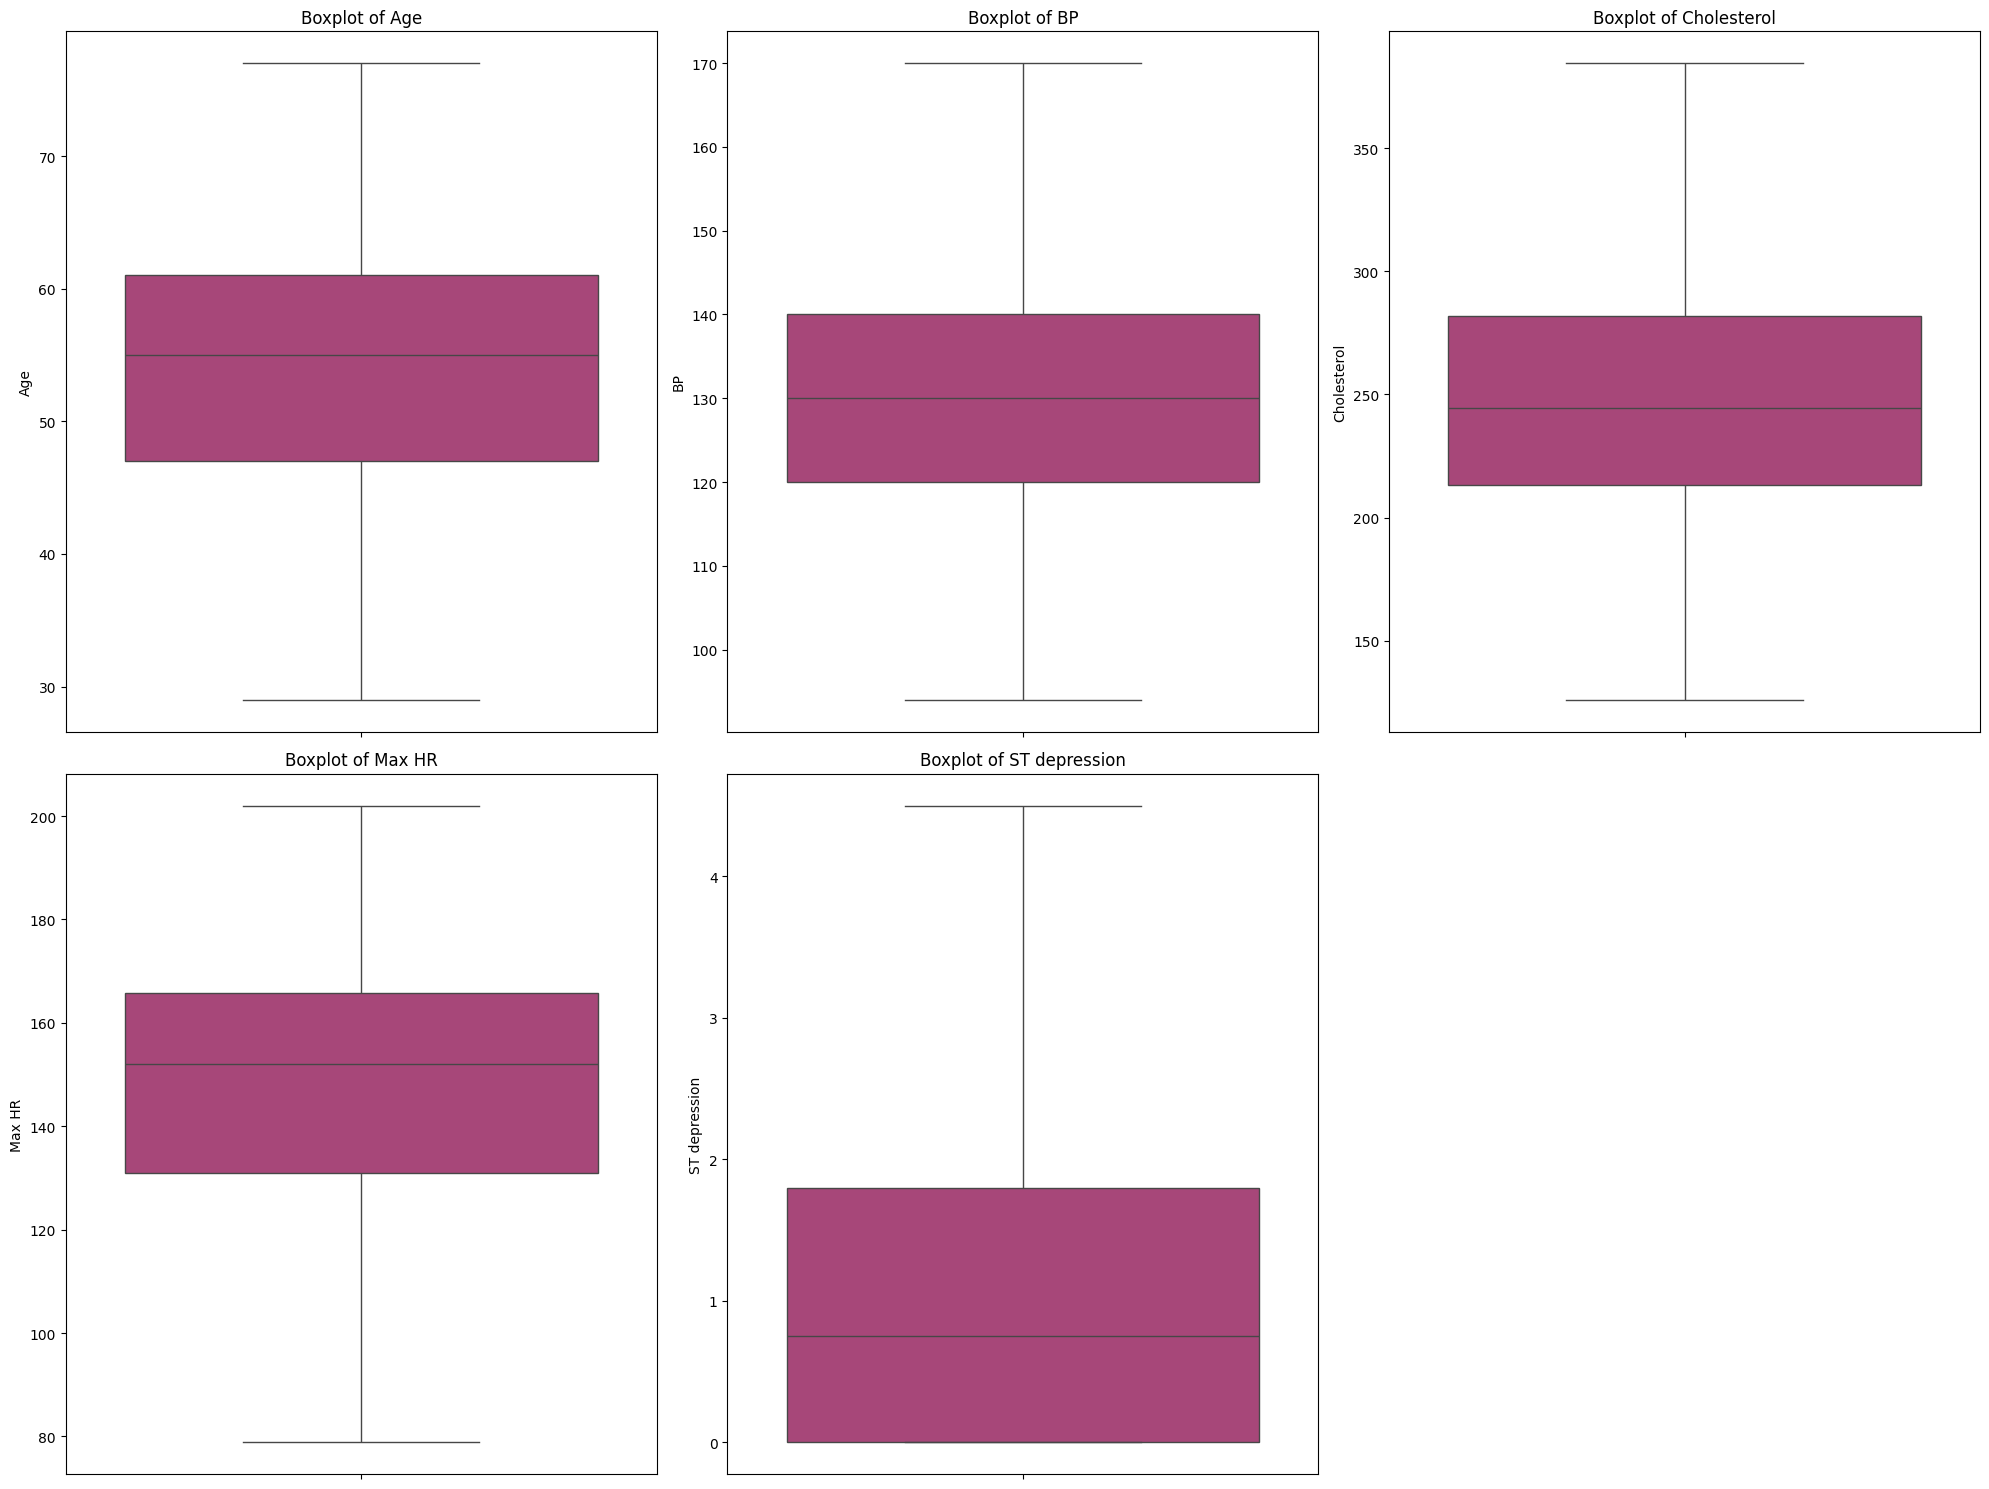

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 15))

axes = axes.flatten()

for i, col in enumerate(checkOutliers):
    sns.boxplot(data=df_train, y=col, ax=axes[i], palette='magma',whis=1.5)
    axes[i].set_title(f'Boxplot of {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Function to handle outliers for TEST
def handle_test_Numerical_outliers(data, train_bounds):
    """
    This function applies train bounds to test data.
    train_bounds: dictionary {column_name: (lower_bound, upper_bound)}
    """
    num_cols = data.select_dtypes(include="number").columns

    for col in num_cols:

            lower_bound, upper_bound = train_bounds[col]


            data[col] = data[col].clip(lower=lower_bound, upper=upper_bound)

    return data

In [ ]:
dfTemp_test = df_test[checkOutliers]

In [ ]:
handle_test_Numerical_outliers(dfTemp_test, bounds)

df_test[checkOutliers]=dfTemp_test[checkOutliers]

In [ ]:
df_test['ST depression'] = np.where(df_test[col] > 4, 4, df_test['ST depression'])

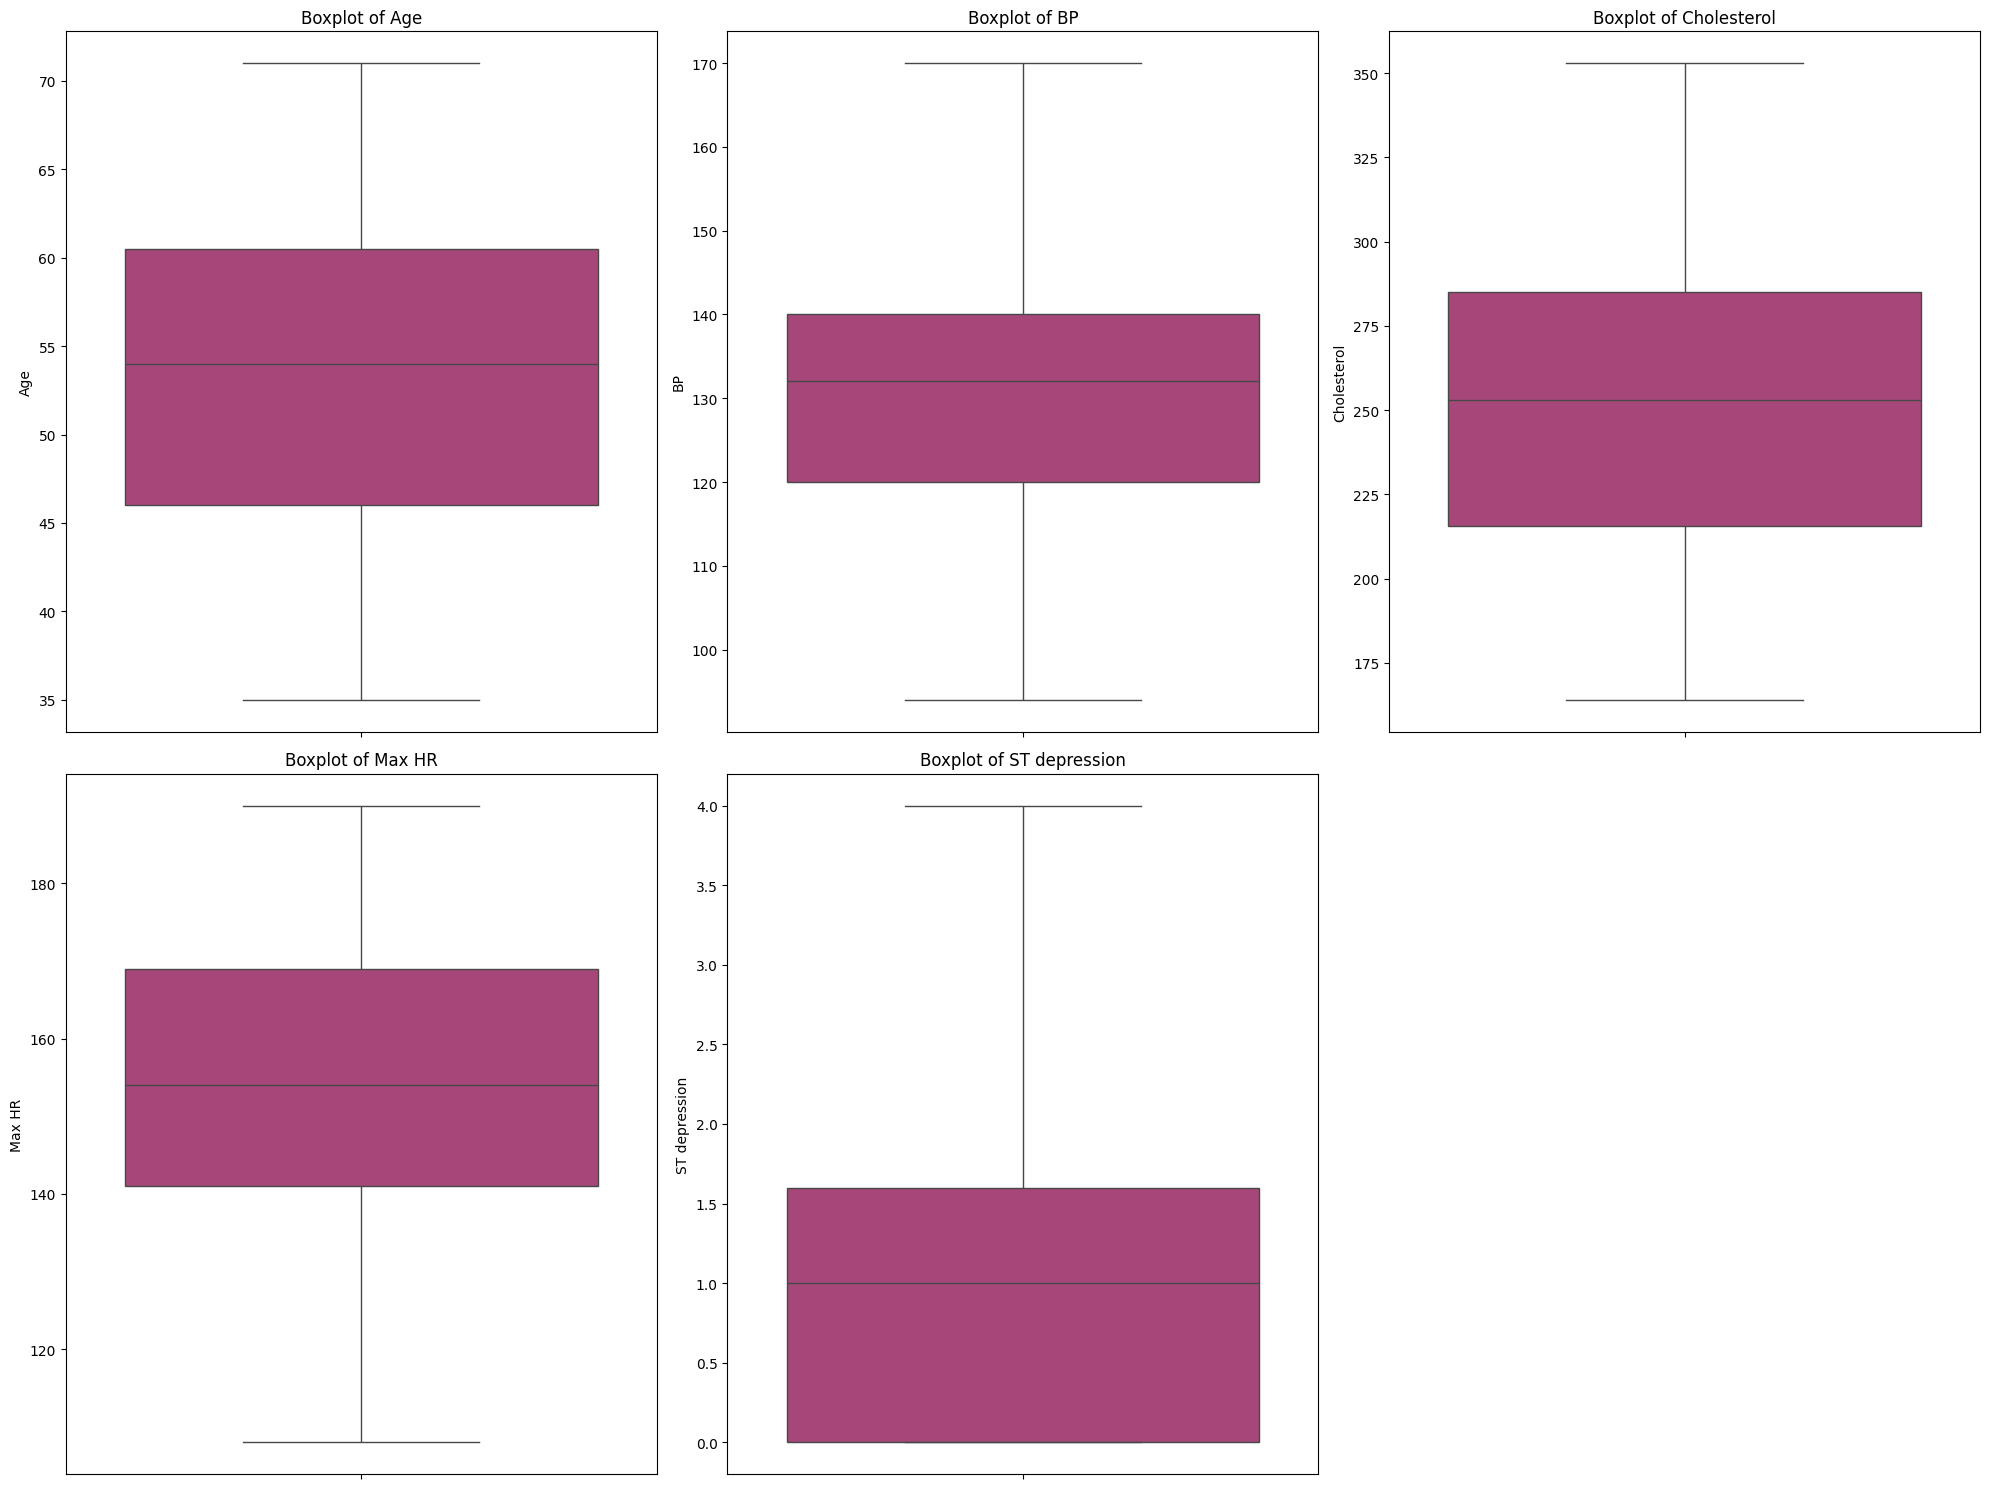

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 15))

axes = axes.flatten()

for i, col in enumerate(checkOutliers):
    sns.boxplot(data=df_test, y=col, ax=axes[i], palette='magma',whis=1.5)
    axes[i].set_title(f'Boxplot of {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [ ]:
data_info(df_test)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,Age,int64,"[44, 60, 43, 58, 54, 51, 52, 62, 63, 41]",26,0,0.0,0
1,Gender,object,"[Female, Male]",2,0,0.0,0
2,Chest pain type,object,"[4, 3, 2, 1]",4,0,0.0,0
3,BP,int64,"[120, 130, 140, 150, 110, 138, 160, 135, 118, ...",16,0,0.0,0
4,Cholesterol,int64,"[219, 204, 252, 227, 220, 258, 254, 168, 330, ...",50,0,0.0,0
5,FBS over 120,object,"[0, 1]",2,0,0.0,0
6,EKG results,object,"[2, 0]",2,0,0.0,0
7,Max HR,int64,"[172, 132, 160, 182, 146, 162, 153, 158, 142, ...",37,0,0.0,0
8,Exercise angina,object,"[0, 1]",2,0,0.0,0
9,ST depression,float64,"[0.0, 1.4, 0.4, 1.0, 2.8, 1.6, 1.8, 1.5, 3.0, ...",17,0,0.0,0


In [ ]:
data_info(df_train)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,Age,int64,"[54, 58, 57, 59, 60, 42, 46, 64, 67, 41]",41,0,0.0,0
1,Gender,object,"[Female, Male]",2,0,0.0,0
2,Chest pain type,object,"[4, 3, 2, 1]",4,0,0.0,0
3,BP,int64,"[120, 130, 140, 110, 150, 125, 170, 160, 128, ...",40,0,0.0,0
4,Cholesterol,float64,"[384.5, 234.0, 226.0, 233.0, 197.0, 269.0, 288...",114,0,0.0,0
5,FBS over 120,object,"[0, 1]",2,0,0.0,0
6,EKG results,object,"[2, 0, 1]",3,0,0.0,0
7,Max HR,float64,"[163.0, 162.0, 125.0, 152.0, 165.0, 150.0, 140...",79,0,0.0,0
8,Exercise angina,object,"[0, 1]",2,0,0.0,0
9,ST depression,float64,"[0.0, 1.2, 0.2, 0.8, 1.6, 1.0, 2.0, 0.6, 1.4, ...",37,0,0.0,0


# Separating Features from Target

In [ ]:
x_train = df_train.drop(columns=['Heart Disease'])
y_train = df_train['Heart Disease']
x_test = df_test.drop(columns=['Heart Disease'])
y_test = df_test['Heart Disease']

In [ ]:
Numerical_Columns=["Age","BP", "Cholesterol", "Max HR","ST depression"]

## Encoding & Scaling

In [ ]:

# Encoding

categorical_cols = x_train.select_dtypes(include=['object']).columns.tolist()



x_train = pd.get_dummies(x_train, columns=categorical_cols)
x_test = pd.get_dummies(x_test, columns=categorical_cols)


x_test = x_test.reindex(columns=x_train.columns, fill_value=0)


In [ ]:
# Scaling

train_min = x_train[Numerical_Columns].min()
train_max = x_train[Numerical_Columns].max()


x_train[Numerical_Columns] = (x_train[Numerical_Columns] - train_min) / (train_max - train_min)
x_test[Numerical_Columns] = (x_test[Numerical_Columns] - train_min) / (train_max - train_min)

In [ ]:
y_train = y_train.map({'No': 0, 'Yes': 1})
y_test = y_test.map({'No': 0, 'Yes': 1})

# Correlation

In [ ]:
f_scores, p_values = f_classif(x_train[Numerical_Columns], y_train)

for col, f_score, p_value in zip(Numerical_Columns, f_scores, p_values):
    print(f"Feature: {col}, F-Score: {f_score:.4f}, P-Value: {p_value:.4f}")

Feature: Age, F-Score: 8.3347, P-Value: 0.0043
Feature: BP, F-Score: 7.2776, P-Value: 0.0076
Feature: Cholesterol, F-Score: 3.3623, P-Value: 0.0682
Feature: Max HR, F-Score: 40.7431, P-Value: 0.0000
Feature: ST depression, F-Score: 41.3589, P-Value: 0.0000


In [ ]:


encoded_cols = [c for c in x_train.columns if c not in Numerical_Columns]
chi_scores, p_values = chi2(x_train[encoded_cols], y_train)

for col, chi, p in zip(encoded_cols, chi_scores, p_values):
    print(f"Feature: {col}, Chi2: {chi:.4f}, P-Value: {p:.4f}")

Feature: Gender_Female, Chi2: 8.0954, P-Value: 0.0044
Feature: Gender_Male, Chi2: 16.9497, P-Value: 0.0000
Feature: Chest pain type_1, Chi2: 0.9628, P-Value: 0.3265
Feature: Chest pain type_2, Chi2: 9.6298, P-Value: 0.0019
Feature: Chest pain type_3, Chi2: 15.6156, P-Value: 0.0001
Feature: Chest pain type_4, Chi2: 25.5949, P-Value: 0.0000
Feature: FBS over 120_0, Chi2: 0.0121, P-Value: 0.9123
Feature: FBS over 120_1, Chi2: 0.0629, P-Value: 0.8020
Feature: EKG results_0, Chi2: 4.8176, P-Value: 0.0282
Feature: EKG results_1, Chi2: 0.0131, P-Value: 0.9087
Feature: EKG results_2, Chi2: 4.4629, P-Value: 0.0346
Feature: Exercise angina_0, Chi2: 12.3670, P-Value: 0.0004
Feature: Exercise angina_1, Chi2: 22.6140, P-Value: 0.0000
Feature: Slope of ST_1, Chi2: 15.6766, P-Value: 0.0001
Feature: Slope of ST_2, Chi2: 15.3320, P-Value: 0.0001
Feature: Slope of ST_3, Chi2: 0.0030, P-Value: 0.9562
Feature: Number of vessels fluro_0, Chi2: 19.2137, P-Value: 0.0000
Feature: Number of vessels fluro_1, Ch

## Model Training

## Logistic Regression Model

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [1,2,3,4,5,6,7,8,9,10],
    'penalty': ['l1', 'l2'],
    'solver': [ 'liblinear','saga'],

}


log_reg = LogisticRegression(random_state=42, max_iter=10000)

grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='roc_auc')

grid_search.fit(x_train, y_train)


print("Best Parameters:", grid_search.best_params_)
print("Best Train Accuracy (from CV):", grid_search.best_score_)


best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)

print("\nFinal Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Train Accuracy (from CV): 0.9219526087947141

Final Test Accuracy: 0.9019607843137255
              precision    recall  f1-score   support

           0       0.87      0.96      0.92        28
           1       0.95      0.83      0.88        23

    accuracy                           0.90        51
   macro avg       0.91      0.90      0.90        51
weighted avg       0.91      0.90      0.90        51



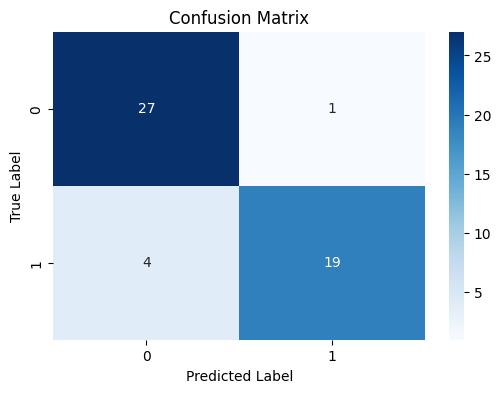

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

##SVM Model

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

C_values = [0.1, 1, 10]
kernels = ['linear', 'rbf']

best_accuracy = 0
best_params = {}

for kernel in kernels:
    for C in C_values:

        model = SVC(
            kernel=kernel,
            C=C
        )

        model.fit(x_train, y_train)

        y_pred = model.predict(x_test)

        acc = accuracy_score(y_test, y_pred)

        print(f"\nKernel = {kernel}, C = {C}")
        print("Accuracy:", acc)
        print(classification_report(y_test, y_pred))


        if acc > best_accuracy:
            best_accuracy = acc
            best_params = {
                "kernel": kernel,
                "C": C
            }


print("\n==========================")
print("Best Accuracy:", best_accuracy)
print("Best Parameters:", best_params)


Kernel = linear, C = 0.1
Accuracy: 0.8431372549019608
              precision    recall  f1-score   support

           0       0.81      0.93      0.87        28
           1       0.89      0.74      0.81        23

    accuracy                           0.84        51
   macro avg       0.85      0.83      0.84        51
weighted avg       0.85      0.84      0.84        51


Kernel = linear, C = 1
Accuracy: 0.8823529411764706
              precision    recall  f1-score   support

           0       0.87      0.93      0.90        28
           1       0.90      0.83      0.86        23

    accuracy                           0.88        51
   macro avg       0.89      0.88      0.88        51
weighted avg       0.88      0.88      0.88        51


Kernel = linear, C = 10
Accuracy: 0.9019607843137255
              precision    recall  f1-score   support

           0       0.87      0.96      0.92        28
           1       0.95      0.83      0.88        23

    accuracy        

##Decision Tree Model

Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Accuracy: 79.76%
Train Accuracy: 86.36%
Test Accuracy: 84.31%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86        28
           1       0.86      0.78      0.82        23

    accuracy                           0.84        51
   macro avg       0.85      0.84      0.84        51
weighted avg       0.84      0.84      0.84        51



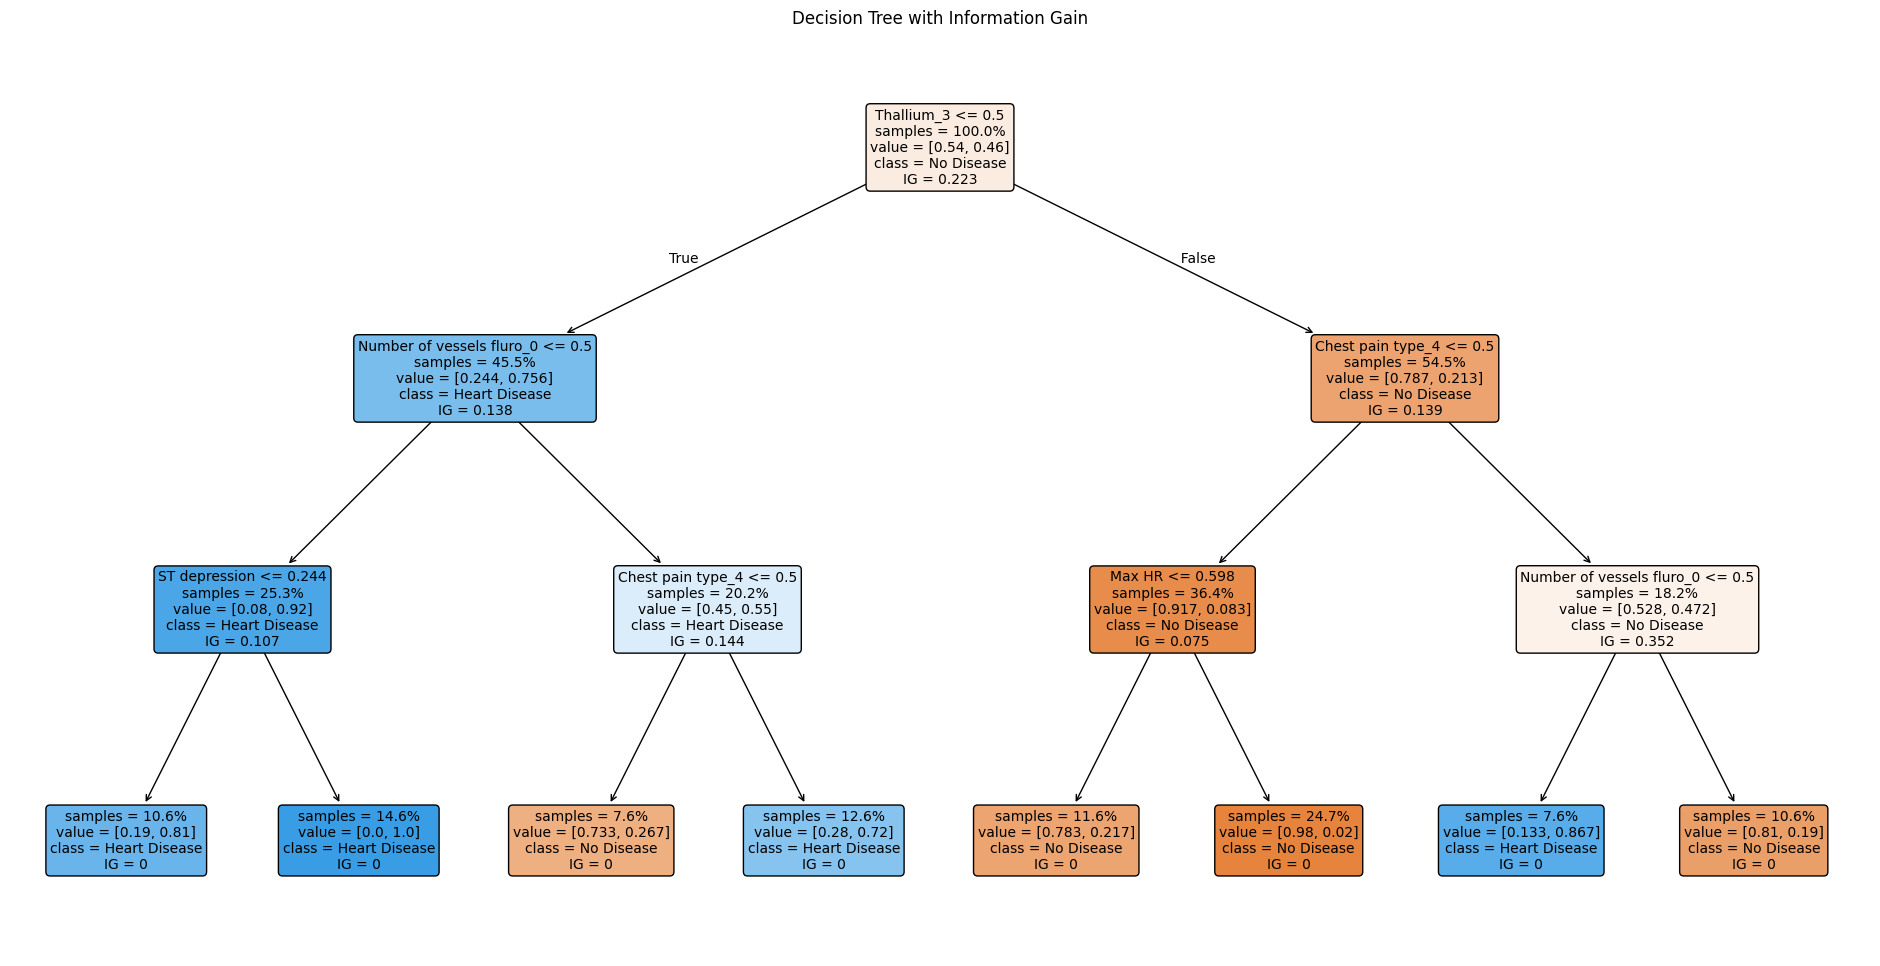

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, _tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

params = {
    'criterion': ['entropy'],
    'max_depth': [3, 4, 5, 6, 7, 8, 10],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(x_train, y_train)

model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", f"{grid.best_score_ * 100:.2f}%")

train_pred = model.predict(x_train)
print("Train Accuracy:", f"{accuracy_score(y_train, train_pred) * 100:.2f}%")

y_pred = model.predict(x_test)
print("Test Accuracy:", f"{accuracy_score(y_test, y_pred) * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

tree = model.tree_

def entropy(node):
    value = tree.value[node][0]
    total = np.sum(value)
    if total == 0:
        return 0
    probs = value / total
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

def info_gain(node):
    if tree.children_left[node] == _tree.TREE_LEAF:
        return 0
    parent_entropy = entropy(node)
    left = tree.children_left[node]
    right = tree.children_right[node]
    n = tree.n_node_samples[node]
    n_left = tree.n_node_samples[left]
    n_right = tree.n_node_samples[right]
    child_entropy = (n_left / n) * entropy(left) + (n_right / n) * entropy(right)
    return parent_entropy - child_entropy

def build_labels():
    labels = []
    for i in range(tree.node_count):
        ig = info_gain(i)
        if tree.children_left[i] == _tree.TREE_LEAF:
            labels.append("IG = 0")
        else:
            labels.append(f"IG = {ig:.3f}")
    return labels

node_labels = build_labels()

plt.figure(figsize=(24, 12))

plot_tree(
    model,
    feature_names=x_train.columns,
    class_names=['No Disease', 'Heart Disease'],
    filled=True,
    rounded=True,
    fontsize=10,
    impurity=False,
    proportion=True
)

ax = plt.gca()

node_index = 0
for text in ax.texts:
    txt = text.get_text()
    if "samples" in txt:
        text.set_text(txt + "\n" + node_labels[node_index])
        node_index += 1

plt.title("Decision Tree with Information Gain")

plt.show()

##KNN MODEL

In [ ]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(x_train, y_train)

y_pred = knn.predict(x_test)




KNN Results:
Accuracy: 0.8823529411764706
Best k : 11
Confusion Matrix:
 [[26  2]
 [ 4 19]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.93      0.90        28
           1       0.90      0.83      0.86        23

    accuracy                           0.88        51
   macro avg       0.89      0.88      0.88        51
weighted avg       0.88      0.88      0.88        51

************************************************************


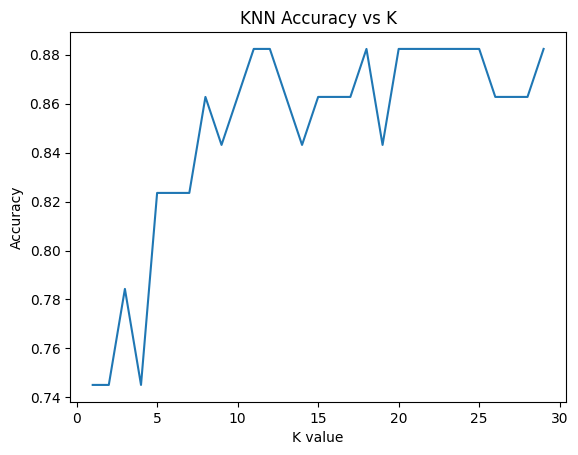

In [ ]:
k_values = []
accuracies = []
best_k=0
best_acc=0

for i in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    if acc > best_acc:
        best_acc = acc
        best_k = i
    k_values.append(i)
    accuracies.append(acc)

def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Results:")
    print("Accuracy:", best_acc)
    print("Best k :", best_k)
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))

evaluate_model("KNN", y_test, y_pred)
print("************************************************************")

plt.plot(k_values, accuracies)
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.show()

##Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
rf= RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 150, 250],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5,7 ],
    'min_samples_split': [4, 6 , 8],
    'min_samples_leaf': [3, 5 , 7],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(x_test)
y_pred_train = best_rf.predict(x_train)

print("Best Parameters:", grid_search.best_params_)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train))

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 100}
Train Accuracy: 0.9343434343434344
Test Accuracy: 0.8627450980392157
